# 04 - Websach Cleaning Validation

Notebook này audit output của cleaning pipeline Websach trước khi chuyển sang feature engineering/modeling. Mục tiêu là kiểm tra artifact, log validation, issue action plan, price consistency giữa các nguồn, warning flags, soft duplicate specs, leakage risk và đưa ra quyết định cuối.

Notebook này không sửa cleaning pipeline hoặc dữ liệu nguồn. Nếu phát hiện lỗi lớn, ghi rõ cần quay lại notebook/pipeline cleaning để sửa.

**Decision labels:** `FAIL`, `PASS_WITH_NON_BLOCKING_WARNINGS`, `PASS`.


## 0. Setup


In [1]:
import os
os.environ.setdefault("PANDAS_USE_PYARROW", "0")
os.environ.setdefault("PYTHONIOENCODING", "utf-8")

import json
import re
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    sns.set_theme(style="whitegrid")
    PLOTTING_AVAILABLE = True
except Exception as exc:
    PLOTTING_AVAILABLE = False
    print(f"Plotting unavailable: {exc}")

try:
    from IPython.display import display, Markdown
except Exception:
    display = print
    Markdown = lambda x: x

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_colwidth", 180)
pd.set_option("display.width", 180)

RANDOM_STATE = 42

def show_note(title, bullets):
    if isinstance(bullets, str):
        bullets = [bullets]
    body = "\n".join(f"- {b}" for b in bullets)
    display(Markdown(f"**Nhận xét - {title}**\n\n{body}"))


In [2]:
PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "data" / "intern").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
DOCS_DIR = PROJECT_ROOT / "docs"
INTERN_DIR = DATA_DIR / "intern"
RAW_DIR = DATA_DIR / "raw"

cleaned_path = INTERN_DIR / "websach_cleaned.csv"
report_path = DOCS_DIR / "websach_cleaning_report.csv"
action_plan_path = DOCS_DIR / "websach_issue_action_plan.csv"
log_path = DOCS_DIR / "websach_cleaning_log.json"
raw_path = RAW_DIR / "clean_laptop_features.csv"

artifact_paths = {
    "cleaned": cleaned_path,
    "cleaning_report": report_path,
    "issue_action_plan": action_plan_path,
    "cleaning_log": log_path,
    "raw_optional": raw_path,
}

artifact_status = pd.DataFrame([
    {
        "artifact": key,
        "path": str(path),
        "exists": path.exists(),
        "size_bytes": path.stat().st_size if path.exists() else np.nan,
    }
    for key, path in artifact_paths.items()
])
artifact_status


,artifact,path,exists,size_bytes
0,cleaned,y:\Python\Laptop-Price-Prediction\data\intern\websach_cleaned.csv,True,2335879
1,cleaning_report,y:\Python\Laptop-Price-Prediction\docs\websach_cleaning_report.csv,True,8868
2,issue_action_plan,y:\Python\Laptop-Price-Prediction\docs\websach_issue_action_plan.csv,True,29832
3,cleaning_log,y:\Python\Laptop-Price-Prediction\docs\websach_cleaning_log.json,True,2113
4,raw_optional,y:\Python\Laptop-Price-Prediction\data\raw\clean_laptop_features.csv,True,593851


### Nhận xét sau setup artifact

Cell này xác nhận notebook đang đọc đúng thư mục dự án và các file đầu vào cần thiết. Nếu một artifact bắt buộc bị thiếu, các phần kiểm định phía sau có thể không tái lập được kết quả cleaning, vì vậy bảng `artifact_status` là lớp kiểm tra đầu tiên trước khi đọc dữ liệu.

## 1. Load Data Và Basic Sanity Check


In [3]:
cleaned = pd.read_csv(cleaned_path)
report = pd.read_csv(report_path)
action_plan = pd.read_csv(action_plan_path)
with open(log_path, "r", encoding="utf-8") as f:
    cleaning_log = json.load(f)
raw = pd.read_csv(raw_path) if raw_path.exists() else None

print(f"Raw shape from file: {None if raw is None else raw.shape}")
print(f"Raw shape from log: {cleaning_log.get('raw_shape')}")
print(f"Cleaned shape from file: {cleaned.shape}")
print(f"Cleaned shape from log: {cleaning_log.get('cleaned_shape')}")
print(f"Cleaning report shape: {report.shape}")
print(f"Issue action plan shape: {action_plan.shape}")
cleaned.head(3)


Raw shape from file: (4384, 15)
Raw shape from log: [4384, 15]
Cleaned shape from file: (4384, 67)
Cleaned shape from log: [4384, 67]
Cleaning report shape: (93, 3)
Issue action plan shape: (57, 9)


,Hãng sản xuất,Công nghệ CPU,Loại CPU,Dung lượng RAM,Loại RAM,Loại ổ cứng,Dung lượng ổ cứng (GB),Đồ họa đã làm sạch,Kích thước (inch),shop_1_price,shop_1_name,shop_2_price,shop_2_name,shop_3_price,shop_3_name,shop_1_price_domain_outlier,shop_1_price_domain,shop_1_price_clean,shop_2_price_domain_outlier,shop_2_price_domain,shop_2_price_clean,shop_3_price_domain_outlier,shop_3_price_domain,shop_3_price_clean,price_row_median_domain,shop_1_price_relative_outlier,shop_2_price_relative_outlier,shop_3_price_relative_outlier,n_prices_raw,n_prices_clean,price_median,price_min_clean,price_max_clean,price_spread_clean_pct,flag_price_spread_warn,flag_price_spread_critical,log_price_median,price_segment,brand_clean,brand_grouped,brand_is_rare,screen_size_clean,screen_size_outlier,screen_size_group,cpu_brand,cpu_tier,cpu_model_clean,ram_gb_clean,ram_capacity_outlier,ram_tier_clean,ram_type_clean,storage_type_clean,storage_gb_clean,storage_gb_outlier,storage_tier_clean,gpu_brand,gpu_tier_v2,product_id,spec_key,is_soft_duplicate_spec,high_end_config_flag,brand_screen_cell_n,low_count_brand_screen_cell,cpu_ram_cell_n,gpu_ram_cell_n,low_count_cpu_ram_cell,low_count_gpu_ram_cell
0,Acer,Intel Core i5,8265U,8.0,DDR4,SSD,512.0,Intel UHD Graphics,14.0,14950000,baochau.vn,15950000,quangmai.net,15990000.0,compro.com.vn,False,14950000.0,14950000.0,False,15950000,15950000.0,False,15990000.0,15990000.0,15950000.0,False,False,False,3,3,15950000.0,14950000.0,15990000.0,0.065204,False,False,16.584969,mid,Acer,Acer,False,14.0,False,14-14.9in,Intel,Mid-range,8265U,8.0,False,<=8GB,DDR4,SSD,512.0,False,512GB,Intel,Intel Integrated,0,Acer|8265U|8.0|512.0|14.0,False,False,84,False,1774,1101,False,False
1,Lg,Intel Core i7,1165G7,16.0,LPDDR4x,SSD,512.0,Intel Iris Xe,17.0,32640000,tiki.vn,47500000,tinhocsangtao.vn,35190000.0,mixicomputer.vn,False,32640000.0,32640000.0,False,47500000,47500000.0,False,35190000.0,35190000.0,35190000.0,False,False,False,3,3,35190000.0,32640000.0,47500000.0,0.422279,True,False,17.376273,high,LG,LG,False,17.0,False,>=17in,Intel,Upper-mid,1165G7,16.0,False,16GB,LPDDR4X,SSD,512.0,False,512GB,Intel,Intel Integrated,1,LG|1165G7|16.0|512.0|17.0,False,False,6,True,1297,753,False,False
2,Lenovo,AMD Ryzen 7,8845HS,16.0,DDR5,SSD,512.0,RTX 4060,16.0,30900000,congnghesgsaigon.com,31490000,tnc.com.vn,33490000.0,tymo.vn,False,30900000.0,30900000.0,False,31490000,31490000.0,False,33490000.0,33490000.0,31490000.0,False,False,False,3,3,31490000.0,30900000.0,33490000.0,0.082248,False,False,17.265181,high,Lenovo,Lenovo,False,16.0,False,16-16.9in,AMD,Upper-mid,8845HS,16.0,False,16GB,DDR5,SSD,512.0,False,512GB,NVIDIA,RTX 4000,2,Lenovo|8845HS|16.0|512.0|16.0,False,True,184,False,252,180,False,False


### Nhận xét sau bước load data

Kết quả shape giúp đối chiếu nhanh giữa file thực tế và cleaning log. Việc hiển thị vài dòng đầu chỉ để kiểm tra schema và kiểu dữ liệu trực quan, không dùng để kết luận chất lượng dữ liệu vì các lỗi hiếm thường nằm ở phần đuôi phân phối hoặc các nhóm warning.

In [4]:
def find_col(df, candidates=(), contains=(), regex=None):
    lower = {c.lower(): c for c in df.columns}
    for c in candidates:
        if c in df.columns:
            return c
        if c.lower() in lower:
            return lower[c.lower()]
    for c in df.columns:
        cl = c.lower()
        if contains and all(tok.lower() in cl for tok in contains):
            return c
        if regex and re.search(regex, c, flags=re.I):
            return c
    return None

def existing(cols):
    seen = set()
    out = []
    for c in cols:
        if c and c in cleaned.columns and c not in seen:
            out.append(c)
            seen.add(c)
    return out

def bool_series(df, col):
    if not col or col not in df.columns:
        return pd.Series(False, index=df.index)
    s = df[col]
    if s.dtype == bool:
        return s.fillna(False)
    return s.astype(str).str.lower().isin(["true", "1", "yes", "y"])

def pct(x, denom):
    return np.nan if denom in [0, None] or pd.isna(denom) else x / denom

def sample_rows(mask, cols, n=10, random_state=RANDOM_STATE):
    cols = existing(cols)
    subset = cleaned.loc[mask, cols]
    if len(subset) > n:
        subset = subset.sample(n=n, random_state=random_state)
    return subset

price_cols = [c for c in ["shop_1_price", "shop_2_price", "shop_3_price"] if c in cleaned.columns]
price_domain_cols = [c for c in ["shop_1_price_domain", "shop_2_price_domain", "shop_3_price_domain"] if c in cleaned.columns]
price_clean_cols = [c for c in ["shop_1_price_clean", "shop_2_price_clean", "shop_3_price_clean"] if c in cleaned.columns]
shop_name_cols = [c for c in ["shop_1_name", "shop_2_name", "shop_3_name"] if c in cleaned.columns]
domain_outlier_cols = [c for c in ["shop_1_price_domain_outlier", "shop_2_price_domain_outlier", "shop_3_price_domain_outlier"] if c in cleaned.columns]
relative_outlier_cols = [c for c in ["shop_1_price_relative_outlier", "shop_2_price_relative_outlier", "shop_3_price_relative_outlier"] if c in cleaned.columns]

COL = {
    "brand_raw": find_col(cleaned, candidates=["Hãng sản xuất"]),
    "brand": find_col(cleaned, candidates=["brand_clean", "brand_grouped", "Hãng sản xuất"]),
    "brand_grouped": find_col(cleaned, candidates=["brand_grouped"]),
    "model": find_col(cleaned, candidates=["model_clean", "product_model", "cpu_model_clean"]),
    "product_name": find_col(cleaned, candidates=["product_name", "title", "name", "Tên sản phẩm"], regex=r"(product|title|name|tên).*"),
    "ram_raw": find_col(cleaned, candidates=["Dung lượng RAM"]),
    "ram": find_col(cleaned, candidates=["ram_gb_clean", "Dung lượng RAM"]),
    "storage_raw": find_col(cleaned, candidates=["Dung lượng ổ cứng (GB)"]),
    "storage": find_col(cleaned, candidates=["storage_gb_clean", "Dung lượng ổ cứng (GB)"]),
    "storage_type": find_col(cleaned, candidates=["storage_type_clean", "Loại ổ cứng"]),
    "screen_raw": find_col(cleaned, candidates=["Kích thước (inch)"]),
    "screen": find_col(cleaned, candidates=["screen_size_clean", "Kích thước (inch)"]),
    "screen_group": find_col(cleaned, candidates=["screen_size_group"]),
    "price_median": find_col(cleaned, candidates=["price_median"]),
    "price_min": find_col(cleaned, candidates=["price_min_clean", "price_min"]),
    "price_max": find_col(cleaned, candidates=["price_max_clean", "price_max"]),
    "price_spread": find_col(cleaned, candidates=["price_spread_clean_pct", "price_spread"]),
    "log_price": find_col(cleaned, candidates=["log_price_median"]),
    "spec_key": find_col(cleaned, candidates=["spec_key"]),
    "product_id": find_col(cleaned, candidates=["product_id"]),
}

flag_cols = [c for c in cleaned.columns if c.startswith("flag_") or c.startswith("is_") or c.endswith("_outlier") or c.startswith("low_count_") or c.endswith("_is_rare")]
core_cols = existing(
    price_cols
    + [COL["price_median"], COL["price_min"], COL["price_max"], COL["price_spread"], COL["brand"], COL["model"], COL["ram"], COL["storage"], COL["screen"]]
    + shop_name_cols
    + flag_cols
)

new_columns = [] if raw is None else [c for c in cleaned.columns if c not in raw.columns]
full_duplicate_rows = int(cleaned.duplicated().sum())

basic_sanity = pd.DataFrame({
    "metric": [
        "cleaned_rows", "cleaned_columns", "raw_rows_file", "raw_columns_file", "raw_rows_log", "cleaned_rows_log",
        "full_duplicate_rows", "new_columns_created", "flag_columns_detected", "product_name_column_available"
    ],
    "value": [
        cleaned.shape[0], cleaned.shape[1], None if raw is None else raw.shape[0], None if raw is None else raw.shape[1],
        cleaning_log.get("raw_shape", [None, None])[0], cleaning_log.get("cleaned_shape", [None, None])[0],
        full_duplicate_rows, len(new_columns), len(flag_cols), COL["product_name"] is not None
    ],
})

dtype_summary = cleaned[core_cols].dtypes.astype(str).reset_index()
dtype_summary.columns = ["column", "dtype"]
dtype_summary["missing_count"] = [int(cleaned[c].isna().sum()) for c in dtype_summary["column"]]
dtype_summary["missing_rate"] = dtype_summary["missing_count"] / len(cleaned)

display(basic_sanity)
display(pd.DataFrame({"new_columns_created": new_columns}))
display(dtype_summary)

notes = [
    f"Cleaned dataset có {cleaned.shape[0]:,} dòng và {cleaned.shape[1]:,} cột; log ghi {cleaning_log.get('cleaned_shape')}.",
    f"Full duplicate rows sau cleaning: {full_duplicate_rows:,}.",
    f"Notebook phát hiện {len(new_columns):,} cột mới và {len(flag_cols):,} cột flag/audit.",
]
if COL["product_name"] is None:
    notes.append("Không thấy cột product name/title trong cleaned/raw input hiện tại; sample review sẽ dùng product_id/spec_key và thông tin cấu hình thay thế.")
show_note("Basic sanity", notes)


,metric,value
0,cleaned_rows,4384
1,cleaned_columns,67
2,raw_rows_file,4384
3,raw_columns_file,15
4,raw_rows_log,4384
5,cleaned_rows_log,4384
6,full_duplicate_rows,0
7,new_columns_created,52
8,flag_columns_detected,16
9,product_name_column_available,True


,new_columns_created
0,shop_1_price_domain_outlier
1,shop_1_price_domain
2,shop_1_price_clean
3,shop_2_price_domain_outlier
4,shop_2_price_domain
5,shop_2_price_clean
6,shop_3_price_domain_outlier
7,shop_3_price_domain
8,shop_3_price_clean
9,price_row_median_domain


,column,dtype,missing_count,missing_rate
0,shop_1_price,int64,0,0.000000
1,shop_2_price,int64,0,0.000000
2,shop_3_price,float64,2,0.000456
3,price_median,float64,0,0.000000
4,price_min_clean,float64,0,0.000000
5,price_max_clean,float64,0,0.000000
6,price_spread_clean_pct,float64,0,0.000000
7,brand_clean,object,0,0.000000
8,cpu_model_clean,object,0,0.000000
9,ram_gb_clean,float64,23,0.005246


**Nhận xét - Basic sanity**

- Cleaned dataset có 4,384 dòng và 67 cột; log ghi [4384, 67].
- Full duplicate rows sau cleaning: 0.
- Notebook phát hiện 52 cột mới và 16 cột flag/audit.

### Nhận xét sau basic sanity check

Bảng sanity tách riêng số dòng/cột, số cột mới, duplicate toàn dòng và tỷ lệ thiếu ở các cột lõi. Phần này giúp đảm bảo pipeline chủ yếu chuẩn hóa, flag hoặc null-out giá trị lỗi thay vì âm thầm làm mất dòng dữ liệu. Các cột mới và cột flag được giữ lại cho audit, nhưng không mặc định trở thành feature modeling.

## 2. Validate Cleaning Log


In [5]:
validation = cleaning_log.get("validation", {})
duplicate_log = cleaning_log.get("duplicate_log", {})
issue_status_counts_log = cleaning_log.get("issue_status_counts", {})
important_rule_counts_log = cleaning_log.get("important_rule_counts", {})
config = cleaning_log.get("config", {})

raw_shape_log = tuple(cleaning_log.get("raw_shape", []))
cleaned_shape_log = tuple(cleaning_log.get("cleaned_shape", []))
row_delta = cleaned_shape_log[0] - raw_shape_log[0] if len(raw_shape_log) == 2 and len(cleaned_shape_log) == 2 else np.nan
row_drop_rate = (-row_delta / raw_shape_log[0]) if len(raw_shape_log) == 2 and raw_shape_log[0] and row_delta < 0 else 0

rows = []
def add_check(name, expected, actual, status, comment):
    rows.append({
        "check_name": name,
        "expected_result": expected,
        "actual_result": actual,
        "status": status,
        "comment": comment,
    })

add_check(
    "artifact_files_exist",
    "All required validation inputs exist",
    bool(artifact_status["exists"].all()),
    "pass" if bool(artifact_status["exists"].all()) else "fail",
    "Missing artifact is blocking because the audit cannot be reproduced." if not bool(artifact_status["exists"].all()) else "All required artifacts are available.",
)
add_check(
    "raw_shape_available",
    "raw_shape exists in cleaning log",
    raw_shape_log,
    "pass" if len(raw_shape_log) == 2 else "fail",
    "Needed to verify row preservation and pipeline scope.",
)
add_check(
    "cleaned_shape_available",
    "cleaned_shape exists in cleaning log",
    cleaned_shape_log,
    "pass" if len(cleaned_shape_log) == 2 else "fail",
    "Needed to verify row preservation and added feature/flag columns.",
)
add_check(
    "row_count_stable",
    "No abnormal row drop; pipeline should mostly flag/null cells",
    f"row_delta={row_delta}, row_drop_rate={row_drop_rate:.2%}",
    "pass" if pd.notna(row_delta) and row_drop_rate <= 0.01 else "fail",
    "Rows are preserved." if row_delta == 0 else "Review whether row filtering was intended.",
)
add_check(
    "full_duplicate_removed",
    "No unexpected full duplicate removal",
    duplicate_log.get("full_duplicate_removed"),
    "pass" if duplicate_log.get("full_duplicate_removed", 0) == 0 else "warn",
    "No full duplicates removed by pipeline." if duplicate_log.get("full_duplicate_removed", 0) == 0 else "Check removed duplicate rows before modeling.",
)

for key, value in validation.items():
    add_check(
        f"core_validation__{key}",
        "True",
        value,
        "pass" if bool(value) else "fail",
        "Core validation passed." if bool(value) else "Blocking issue: this validation is false.",
    )

for key, value in important_rule_counts_log.items():
    expected = "Count is present and reviewed"
    status = "pass"
    comment = "Important warning/action count captured for audit."
    if key in ["price_spread_warn_rows", "price_spread_critical_rows", "soft_duplicate_spec_rows"] and value > 0:
        status = "warn"
        comment = "Non-blocking but important for modeling and sampling review."
    add_check(f"important_rule_count__{key}", expected, value, status, comment)

validation_check_summary = pd.DataFrame(rows)
display(validation_check_summary)

blocking_checks = validation_check_summary[validation_check_summary["status"].eq("fail")]
show_note(
    "Cleaning log",
    [
        f"Blocking checks: {len(blocking_checks):,}.",
        f"Core validation pass count: {sum(bool(v) for v in validation.values())}/{len(validation)}.",
        f"Issue status counts in log: {issue_status_counts_log}.",
        f"Important rule counts: {important_rule_counts_log}.",
    ],
)


,check_name,expected_result,actual_result,status,comment
0,artifact_files_exist,All required validation inputs exist,True,pass,All required artifacts are available.
1,raw_shape_available,raw_shape exists in cleaning log,"(4384, 15)",pass,Needed to verify row preservation and pipeline scope.
2,cleaned_shape_available,cleaned_shape exists in cleaning log,"(4384, 67)",pass,Needed to verify row preservation and added feature/flag columns.
3,row_count_stable,No abnormal row drop; pipeline should mostly flag/null cells,"row_delta=0, row_drop_rate=0.00%",pass,Rows are preserved.
4,full_duplicate_removed,No unexpected full duplicate removal,0,pass,No full duplicates removed by pipeline.
5,core_validation__price_median_numeric,True,True,pass,Core validation passed.
6,core_validation__price_median_not_missing,True,True,pass,Core validation passed.
7,core_validation__domain_prices_in_range,True,True,pass,Core validation passed.
8,core_validation__screen_range_valid_or_missing,True,True,pass,Core validation passed.
9,core_validation__ram_range_valid_or_missing,True,True,pass,Core validation passed.


**Nhận xét - Cleaning log**

- Blocking checks: 0.
- Core validation pass count: 8/8.
- Issue status counts in log: {'needs_manual_review': 34, 'resolved': 12, 'partially_resolved': 11}.
- Important rule counts: {'domain_price_cells_nulled': 4, 'relative_price_cells_nulled': 53, 'price_spread_warn_rows': 583, 'price_spread_critical_rows': 142, 'screen_size_outlier_nulled': 85, 'ram_capacity_outlier_nulled': 2, 'soft_duplicate_spec_rows': 2516}.

### Nhận xét sau cleaning log validation

Các check trong phần này kiểm tra tính nhất quán giữa log và dữ liệu đã xuất. Check `fail` ở đây là lỗi chặn vì notebook không thể tin tưởng artifact đầu vào; check `warn` chỉ báo dữ liệu cần review thêm, ví dụ price spread hoặc soft duplicate, nhưng chưa đủ lý do để loại bỏ toàn bộ dataset.

## 3. Audit-only diagnostics - Action plan review

In [6]:
issue_status_summary = (
    action_plan.groupby("resolution_status", dropna=False)
    .size()
    .reset_index(name="issue_count")
    .sort_values("issue_count", ascending=False)
)

issue_group_status_summary = (
    action_plan.groupby(["issue_group", "resolution_status"], dropna=False)
    .size()
    .reset_index(name="issue_count")
    .sort_values(["issue_group", "issue_count"], ascending=[True, False])
)

manual_review_issues = action_plan[action_plan["resolution_status"].eq("needs_manual_review")].copy()
partial_resolution_issues = action_plan[action_plan["resolution_status"].eq("partially_resolved")].copy()
high_unresolved_issues = action_plan[action_plan["severity"].eq("high") & ~action_plan["resolution_status"].eq("resolved")].copy()

def classify_manual_review(row):
    text = " ".join(str(row.get(c, "")) for c in ["issue_key", "issue_group", "affected_column", "issue_description", "proposed_action", "final_action"]).lower()
    if any(k in text for k in ["model", "log-transform", "feature", "encoding", "bucket", "one-hot", "interaction"]):
        return "chuyển sang feature engineering"
    if any(k in text for k in ["mapping", "rule", "null-out", "parse", "clean", "alias"]):
        return "cần thêm rule cleaning"
    if any(k in text for k in ["note", "raw", "manual", "lookup", "audit", "review"]):
        return "cần xem lại EDA note/raw data"
    return "có thể bỏ qua vì không ảnh hưởng modeling"

manual_review_issues["manual_review_classification"] = manual_review_issues.apply(classify_manual_review, axis=1)

display(pd.DataFrame({"metric": ["total_issues"], "value": [len(action_plan)]}))
display(issue_status_summary)
display(issue_group_status_summary)
display(high_unresolved_issues[["issue_key", "severity", "affected_column", "issue_group", "resolution_status", "final_action"]])
display(manual_review_issues[["issue_key", "severity", "affected_column", "issue_group", "manual_review_classification", "final_action"]])
display(partial_resolution_issues[["issue_key", "severity", "affected_column", "issue_group", "final_action"]])

show_note(
    "Issue action plan",
    [
        f"Total issues: {len(action_plan):,}; status summary: {issue_status_summary.set_index('resolution_status')['issue_count'].to_dict()}.",
        f"High severity unresolved/non-resolved issues: {len(high_unresolved_issues):,}; cần review trước khi chốt modeling assumptions.",
        "Các issue manual review được phân loại thành: bỏ qua/modeling, thêm rule cleaning, chuyển feature engineering, hoặc xem lại EDA/raw notes.",
    ],
)


,metric,value
0,total_issues,57


,resolution_status,issue_count
0,needs_manual_review,34
2,resolved,12
1,partially_resolved,11


,issue_group,resolution_status,issue_count
0,cpu_parsing_grouping,needs_manual_review,4
1,gpu_parsing_grouping,resolved,1
3,missing_unknown_values,partially_resolved,3
2,missing_unknown_values,needs_manual_review,1
4,price_related_issues,needs_manual_review,27
6,price_related_issues,resolved,11
5,price_related_issues,partially_resolved,8
7,ram_parsing_grouping,needs_manual_review,1
8,storage_parsing_grouping,needs_manual_review,1


,issue_key,severity,affected_column,issue_group,resolution_status,final_action
3,price_spread_between_sources,high,shop_*_price/price_median,price_related_issues,needs_manual_review,Documented; no deterministic cleaning required.
7,screen_size_missing_values,high,Kích thước (inch),price_related_issues,needs_manual_review,Document as modeling guidance; keep engineered helper columns where useful.
9,screen_size_fragmentation,high,Kích thước (inch),price_related_issues,partially_resolved,Keep Unknown/tier flags instead of dropping rows.
15,cpu_brand_unknown_values,high,Công nghệ CPU/Loại CPU,missing_unknown_values,partially_resolved,Keep Unknown/tier flags instead of dropping rows.
16,cpu_model_high_cardinality,high,Công nghệ CPU/Loại CPU,cpu_parsing_grouping,needs_manual_review,Document as modeling guidance; keep engineered helper columns where useful.
17,cpu_tier_unknown_values,high,Công nghệ CPU/Loại CPU,price_related_issues,needs_manual_review,Document as modeling guidance; keep engineered helper columns where useful.
19,ram_capacity_missing_values,high,Dung lượng RAM/Loại RAM,price_related_issues,needs_manual_review,Document as modeling guidance; keep engineered helper columns where useful.
21,ram_capacity_fragmentation,high,Dung lượng RAM/Loại RAM,price_related_issues,partially_resolved,Keep Unknown/tier flags instead of dropping rows.
23,ram_type_missing_unknown,high,Dung lượng RAM/Loại RAM,price_related_issues,partially_resolved,Keep Unknown/tier flags instead of dropping rows.
24,ram_type_inconsistent_labels,high,Dung lượng RAM/Loại RAM,price_related_issues,partially_resolved,Keep Unknown/tier flags instead of dropping rows.


,issue_key,severity,affected_column,issue_group,manual_review_classification,final_action
0,price_slots_not_fixed_shops,low,shop_*_price/price_median,price_related_issues,cần thêm rule cleaning,Documented; no deterministic cleaning required.
3,price_spread_between_sources,high,shop_*_price/price_median,price_related_issues,cần thêm rule cleaning,Documented; no deterministic cleaning required.
4,price_right_skewed_distribution,low,shop_*_price/price_median,price_related_issues,chuyển sang feature engineering,Document as modeling guidance; keep engineered helper columns where useful.
5,price_high_tail_valid_but_influential,low,shop_*_price/price_median,price_related_issues,chuyển sang feature engineering,Document as modeling guidance; keep engineered helper columns where useful.
7,screen_size_missing_values,high,Kích thước (inch),price_related_issues,chuyển sang feature engineering,Document as modeling guidance; keep engineered helper columns where useful.
10,screen_size_class_imbalance,medium,Kích thước (inch),price_related_issues,cần thêm rule cleaning,Documented; no deterministic cleaning required.
11,screen_size_price_confounding,medium,Kích thước (inch),price_related_issues,chuyển sang feature engineering,Document as modeling guidance; keep engineered helper columns where useful.
12,brand_screen_interaction,low,Kích thước (inch),price_related_issues,chuyển sang feature engineering,Document as modeling guidance; keep engineered helper columns where useful.
14,cpu_brand_class_imbalance,medium,Công nghệ CPU/Loại CPU,cpu_parsing_grouping,chuyển sang feature engineering,Document as modeling guidance; keep engineered helper columns where useful.
16,cpu_model_high_cardinality,high,Công nghệ CPU/Loại CPU,cpu_parsing_grouping,chuyển sang feature engineering,Document as modeling guidance; keep engineered helper columns where useful.


,issue_key,severity,affected_column,issue_group,final_action
9,screen_size_fragmentation,high,Kích thước (inch),price_related_issues,Keep Unknown/tier flags instead of dropping rows.
15,cpu_brand_unknown_values,high,Công nghệ CPU/Loại CPU,missing_unknown_values,Keep Unknown/tier flags instead of dropping rows.
21,ram_capacity_fragmentation,high,Dung lượng RAM/Loại RAM,price_related_issues,Keep Unknown/tier flags instead of dropping rows.
23,ram_type_missing_unknown,high,Dung lượng RAM/Loại RAM,price_related_issues,Keep Unknown/tier flags instead of dropping rows.
24,ram_type_inconsistent_labels,high,Dung lượng RAM/Loại RAM,price_related_issues,Keep Unknown/tier flags instead of dropping rows.
29,storage_type_missing_unknown,high,Loại ổ cứng/Dung lượng ổ cứng (GB),price_related_issues,Keep Unknown/tier flags instead of dropping rows.
30,storage_type_inconsistent_labels,high,Loại ổ cứng/Dung lượng ổ cứng (GB),price_related_issues,Keep Unknown/tier flags instead of dropping rows.
33,storage_capacity_fragmentation,high,Loại ổ cứng/Dung lượng ổ cứng (GB),price_related_issues,Keep Unknown/tier flags instead of dropping rows.
36,gpu_unknown_values,high,Đồ họa đã làm sạch,price_related_issues,Keep Unknown/tier flags instead of dropping rows.
47,numeric_missing_values,high,NaN,missing_unknown_values,Keep Unknown/tier flags instead of dropping rows.


**Nhận xét - Issue action plan**

- Total issues: 57; status summary: {'needs_manual_review': 34, 'resolved': 12, 'partially_resolved': 11}.
- High severity unresolved/non-resolved issues: 24; cần review trước khi chốt modeling assumptions.
- Các issue manual review được phân loại thành: bỏ qua/modeling, thêm rule cleaning, chuyển feature engineering, hoặc xem lại EDA/raw notes.

### Nhận xét sau action plan review

Bảng action plan cho biết issue nào đã xử lý, issue nào còn cần manual review hoặc chỉ được xử lý một phần. Các dòng `needs_manual_review` và `partially_resolved` được xem là cảnh báo không chặn: chúng cần được ghi nhận trong validation report, nhưng không làm fail modeling-ready dataset nếu target và feature contract vẫn an toàn.

## 4. Audit-only diagnostics - Price validation overview

,column,dtype,missing_count,missing_rate,min,max,mean,median,count_le_0,"count_below_3,000,000","count_above_200,000,000"
0,shop_1_price,int64,0,0.000000,3400000.0,8.600000e+08,2.557785e+07,2.069000e+07,0,0,1
1,shop_2_price,int64,0,0.000000,3000000.0,1.794000e+08,2.596381e+07,2.125000e+07,0,0,0
2,shop_3_price,float64,2,0.000456,3498000.0,2.750000e+09,2.777876e+07,2.169900e+07,0,0,3
3,shop_1_price_clean,float64,33,0.007527,3400000.0,1.769900e+08,2.541335e+07,2.078000e+07,0,0,0
4,shop_2_price_clean,float64,8,0.001825,3000000.0,1.794000e+08,2.598591e+07,2.127000e+07,0,0,0
5,shop_3_price_clean,float64,18,0.004106,3498000.0,1.817400e+08,2.674330e+07,2.169000e+07,0,0,0
6,price_median,float64,0,0.000000,3470000.0,1.794000e+08,2.603173e+07,2.119000e+07,0,0,0
7,price_min_clean,float64,0,0.000000,3000000.0,1.769900e+08,2.424709e+07,1.977000e+07,0,0,0
8,price_max_clean,float64,0,0.000000,3498000.0,1.817400e+08,2.777930e+07,2.262150e+07,0,0,0
9,price_spread_clean_pct,float64,0,0.000000,0.0,1.267306e+00,1.479704e-01,9.876073e-02,18,4384,0


,metric,value,log_value
0,domain_price_cells_nulled_actual,4,4.0
1,relative_price_cells_nulled_actual,53,53.0
2,price_median_missing,0,NaN


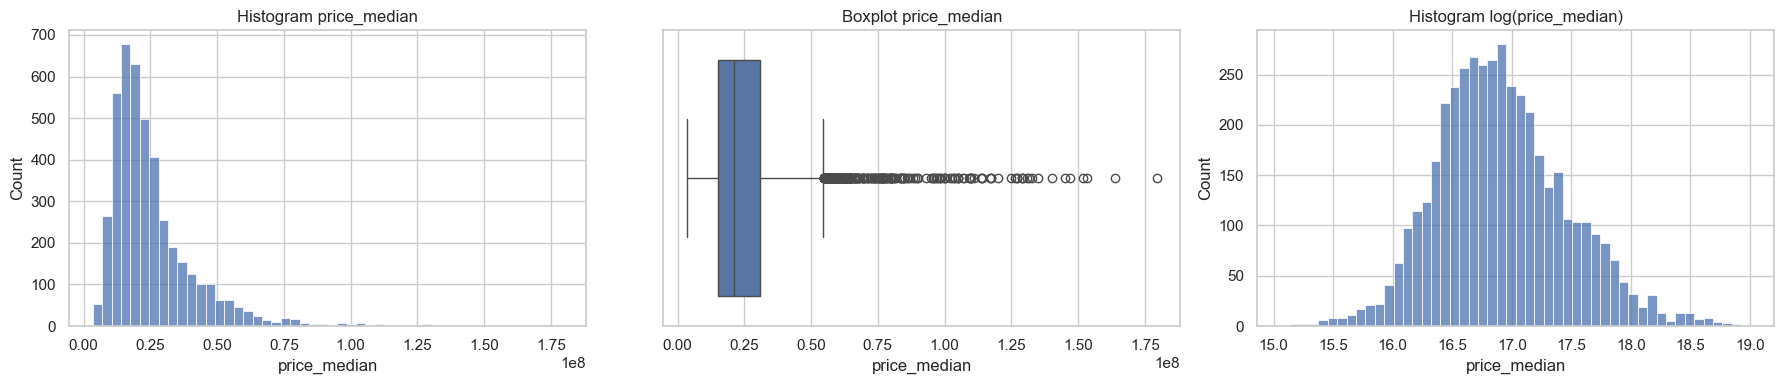

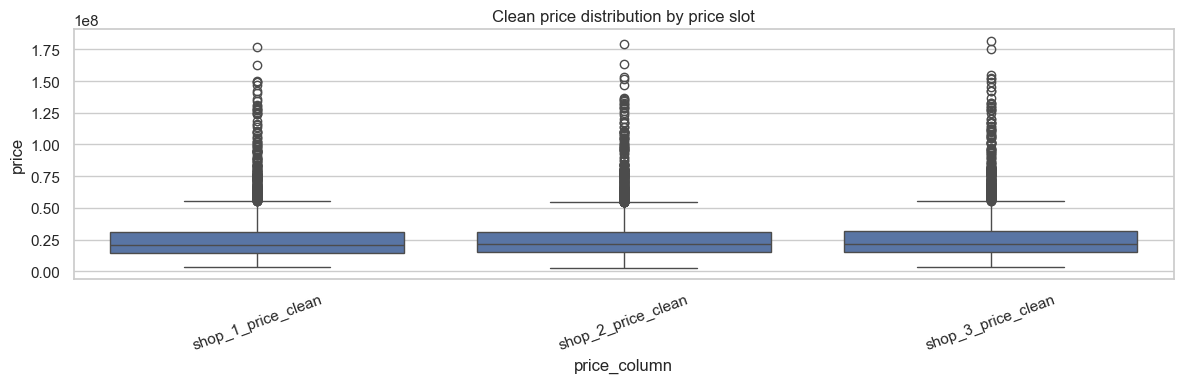

**Nhận xét - Price tổng quan**

- price_median missing: 0; đây là target candidate ổn định hơn shop-specific slots.
- Domain outlier cells actual/log: 4/4. Relative outlier cells actual/log: 53/53.
- Nếu target là price_median, không dùng trực tiếp shop price, price_min hoặc price_max làm feature vì leakage.

In [7]:
price_min_threshold = config.get("price_min", 3_000_000)
price_max_threshold = config.get("price_max", 200_000_000)

price_overview_rows = []
for col in price_cols + price_clean_cols + existing([COL["price_median"], COL["price_min"], COL["price_max"], COL["price_spread"]]):
    s = pd.to_numeric(cleaned[col], errors="coerce")
    price_overview_rows.append({
        "column": col,
        "dtype": str(cleaned[col].dtype),
        "missing_count": int(s.isna().sum()),
        "missing_rate": s.isna().mean(),
        "min": s.min(),
        "max": s.max(),
        "mean": s.mean(),
        "median": s.median(),
        "count_le_0": int((s <= 0).sum()),
        f"count_below_{price_min_threshold:,}": int((s < price_min_threshold).sum()),
        f"count_above_{price_max_threshold:,}": int((s > price_max_threshold).sum()),
    })
price_overview = pd.DataFrame(price_overview_rows)

domain_price_cells_nulled_actual = int(sum(bool_series(cleaned, c).sum() for c in domain_outlier_cols))
relative_price_cells_nulled_actual = int(sum(bool_series(cleaned, c).sum() for c in relative_outlier_cols))
price_median_missing = int(cleaned[COL["price_median"]].isna().sum()) if COL["price_median"] else np.nan

display(price_overview)
display(pd.DataFrame([
    {"metric": "domain_price_cells_nulled_actual", "value": domain_price_cells_nulled_actual, "log_value": important_rule_counts_log.get("domain_price_cells_nulled")},
    {"metric": "relative_price_cells_nulled_actual", "value": relative_price_cells_nulled_actual, "log_value": important_rule_counts_log.get("relative_price_cells_nulled")},
    {"metric": "price_median_missing", "value": price_median_missing, "log_value": None},
]))

if PLOTTING_AVAILABLE and COL["price_median"]:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    sns.histplot(cleaned[COL["price_median"]], bins=50, ax=axes[0])
    axes[0].set_title("Histogram price_median")
    sns.boxplot(x=cleaned[COL["price_median"]], ax=axes[1])
    axes[1].set_title("Boxplot price_median")
    sns.histplot(np.log1p(cleaned[COL["price_median"]]), bins=50, ax=axes[2])
    axes[2].set_title("Histogram log(price_median)")
    plt.tight_layout()
    plt.show()

    if price_clean_cols:
        price_long = cleaned[price_clean_cols].melt(var_name="price_column", value_name="price")
        plt.figure(figsize=(12, 4))
        sns.boxplot(data=price_long, x="price_column", y="price")
        plt.title("Clean price distribution by price slot")
        plt.xticks(rotation=20)
        plt.tight_layout()
        plt.show()

show_note(
    "Price tổng quan",
    [
        f"price_median missing: {price_median_missing:,}; đây là target candidate ổn định hơn shop-specific slots.",
        f"Domain outlier cells actual/log: {domain_price_cells_nulled_actual}/{important_rule_counts_log.get('domain_price_cells_nulled')}. Relative outlier cells actual/log: {relative_price_cells_nulled_actual}/{important_rule_counts_log.get('relative_price_cells_nulled')}.",
        "Nếu target là price_median, không dùng trực tiếp shop price, price_min hoặc price_max làm feature vì leakage.",
    ],
)


### Nhận xét sau price overview

Histogram và boxplot của `price_median` dùng để nhìn phân phối target, độ lệch phải và các điểm giá cao bất thường. Các bảng min/max/missing cho shop price và clean price giúp xác nhận rule domain/relative outlier đã null các price cell có vấn đề. Những cột giá này chỉ phục vụ QC và target construction; chúng không được đưa vào `feature_cols` để tránh leakage.

## 5. Non-blocking warning review - Price spread QC

,metric,actual,log_value
0,price_spread_warn_rows,583,583.0
1,price_spread_critical_rows,142,142.0
2,rows_spread_gt_0_3,583,NaN
3,rows_spread_gt_0_5,142,NaN


,price_spread
count,4384.000000
mean,0.147970
std,0.149898
min,0.000000
50%,0.098761
75%,0.206703
90%,0.341430
95%,0.438587
99%,0.724995
max,1.267306


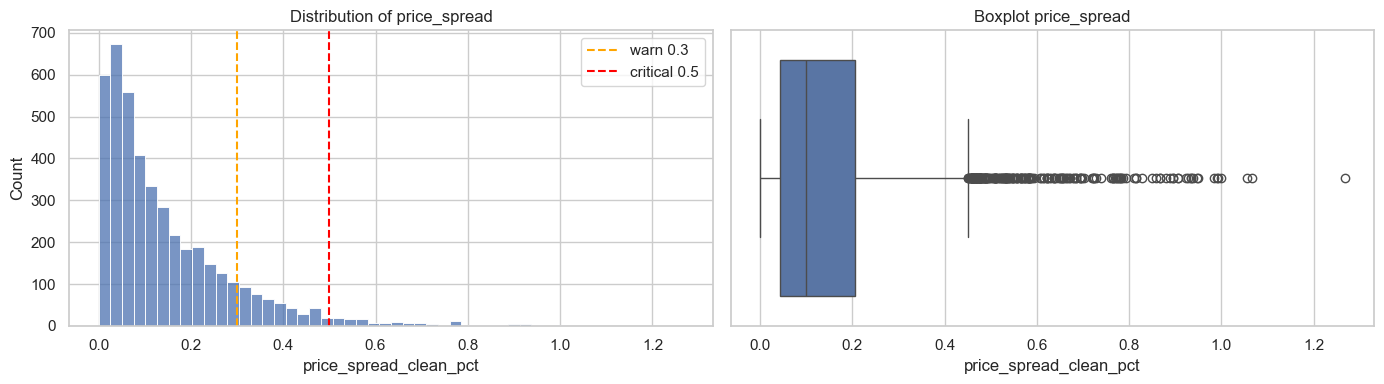

,brand_clean,n,median_spread,mean_spread,critical_rate
17,Razer,1,0.609905,0.609905,1.000000
14,Masstel,2,0.444792,0.444792,0.500000
18,Samsung,14,0.226550,0.313629,0.214286
11,LG,33,0.226913,0.258465,0.090909
19,Surface,14,0.088820,0.160588,0.071429
16,Microsoft,89,0.114989,0.158136,0.044944
13,MSI,275,0.108297,0.155697,0.040000
21,Unknown,180,0.113775,0.158524,0.038889
9,HP,832,0.100595,0.156203,0.036058
1,Acer,314,0.108711,0.154434,0.035032


,_price_bin_tmp,n,median_spread,critical_rows
0,"(3469999.999, 14000000.0]",878,0.121663,72
1,"(14000000.0, 18590000.0]",880,0.092486,21
2,"(18590000.0, 24198000.0]",872,0.095731,23
3,"(24198000.0, 34800000.0]",878,0.095968,12
4,"(34800000.0, 179400000.0]",876,0.089397,14


,shop_combination_available,n,median_spread,mean_spread
3,111,4325,0.100000,0.149236
0,011,33,0.041720,0.051746
2,110,18,0.040019,0.064851
1,101,8,0.034180,0.047576


,shop_name,n,avg_deviation,median_abs_deviation
646,tashop.com.vn,17,-0.037771,0.196319
270,laptop3mien.vn,7,0.178468,0.190792
261,laptop127.vn,6,-0.013355,0.177696
511,nese.vn,9,-0.169279,0.160792
9,acervn.com,5,-0.139332,0.147530
744,vienai.com,6,-0.083745,0.144851
801,vodien.vn,70,-0.144520,0.141314
355,laptopvui.com,8,-0.138196,0.139873
778,vitinhhoangvu.com,5,-0.061057,0.139322
297,laptophd.vn,5,-0.085081,0.137398


**Critical spread sample**

...

**One source low relative to median sample**

,shop_1_name,product_id,spec_key,brand_clean,cpu_model_clean,ram_gb_clean,storage_gb_clean,screen_size_clean,shop_2_name,shop_3_name,shop_1_price_clean,shop_2_price_clean,shop_3_price_clean,price_median,price_spread_clean_pct,flag_price_spread_warn,flag_price_spread_critical
421,huynhgiastore.com,421,HP|11800H|Unknown|512.0|16.1,HP,11800H,NaN,512.0,16.1,skygear.vn,mua8.com,20990000.0,34690000.0,34990000.0,34690000.0,0.403575,True,False
121,hkc.vn,121,MSI|1280P|16.0|512.0|14.0,MSI,1280P,16.0,512.0,14.0,shopee.vn,laptop15.vn,21500000.0,34000000.0,14900000.0,21500000.0,0.888372,True,True
2883,maytinhgiare.vn,2883,ASUS|1135G7|4.0|Unknown|14.0,ASUS,1135G7,4.0,NaN,14.0,sondat.vn,svcvietnam.com.vn,9190000.0,13590000.0,16890000.0,13590000.0,0.566593,True,True
4219,shopee.vn,4219,HP|8265U|4.0|1024.0|15.6,HP,8265U,4.0,1024.0,15.6,maytinhquanganh.com,laptopvui.com,15500000.0,6899000.0,9500000.0,9500000.0,0.905368,True,True
4295,mytholaptop.vn,4295,Acer|10210U|4.0|256.0|15.6,Acer,10210U,4.0,256.0,15.6,laptoptld.com,laptopfull.com,5990000.0,11890000.0,12390000.0,11890000.0,0.538267,True,True
3245,dhctaynguyen.com,3245,ASUS|6200U|4.0|500.0|15.6,ASUS,6200U,4.0,500.0,15.6,laptopnhatminh.com,osc.vn,4900000.0,9790000.0,12390000.0,9790000.0,0.765066,True,True
3924,vanphatmobile.com,3924,Samsung|1360P|16.0|Unknown|16.0,Samsung,1360P,16.0,NaN,16.0,centerlap.com,laptopx360.vn,20900000.0,28490000.0,39490000.0,28490000.0,0.652510,True,True
2831,duyhai.vn,2831,Dell|12800H|32.0|Unknown|14.0,Dell,12800H,32.0,NaN,14.0,laptop3mien.vn,kinglap.vn,35900000.0,59900000.0,62000000.0,59900000.0,0.435726,True,False
152,onlylap.vn,152,Dell|884OU|16.0|1024.0|16.0,Dell,884OU,16.0,1024.0,16.0,laptopvip.vn,compumax.com.vn,11990000.0,16490000.0,16490000.0,16490000.0,0.272893,False,False
2203,cellphones.com.vn,2203,Acer|13420H|16.0|512.0|15.6,Acer,13420H,16.0,512.0,15.6,dienmayxanh.com,hkc.vn,17590000.0,23990000.0,26000000.0,23990000.0,0.350563,True,False


**One source high relative to median sample**

,shop_1_name,product_id,spec_key,brand_clean,cpu_model_clean,ram_gb_clean,storage_gb_clean,screen_size_clean,shop_2_name,shop_3_name,shop_1_price_clean,shop_2_price_clean,shop_3_price_clean,price_median,price_spread_clean_pct,flag_price_spread_warn,flag_price_spread_critical
4122,surfaceviet.vn,4122,Microsoft|165U|32.0|1024.0|13.0,Microsoft,165U,32.0,1024.0,13.0,surfacecenter.com.vn,surface24h.vn,58900000.0,42990000.0,44000000.0,44000000.0,0.361591,True,False
142,ben.com.vn,142,MSI|1235U|8.0|512.0|14.0,MSI,1235U,8.0,512.0,14.0,vitinhminhhoang.vn,songphuong.vn,17388000.0,13355000.0,13590000.0,13590000.0,0.296762,False,False
643,tinhocsangtao.vn,643,LG|1135G7|8.0|512.0|16.0,LG,1135G7,8.0,512.0,16.0,eaz.com.vn,vientin.com.vn,36090000.0,23399000.0,27490000.0,27490000.0,0.461659,True,False
710,tinhocsangtao.vn,710,HP|3750H|8.0|512.0|15.6,HP,3750H,8.0,512.0,15.6,vitinhsangtao.vn,compro.com.vn,18400000.0,18400000.0,25900000.0,18400000.0,0.407609,True,False
272,shopee.vn,272,HP|10210U|8.0|256.0|14.0,HP,10210U,8.0,256.0,14.0,laptoprenhat.vn,laptophitech.vn,13900000.0,7390000.0,7500000.0,7500000.0,0.868000,True,True
738,maytinhquanganh.com,738,HP|6100U|4.0|500.0|14.0,HP,6100U,4.0,500.0,14.0,transustore.com,laptopminhha.vn,3799000.0,4500000.0,8000000.0,4500000.0,0.933556,True,True
1192,shopee.vn,1192,ASUS|6800H|8.0|512.0|15.6,ASUS,6800H,8.0,512.0,15.6,techcare.vn,xrazer.vn,34999000.0,19800000.0,20990000.0,20990000.0,0.724107,True,True
2573,sintech.vn,2573,MSI|8300H|8.0|1024.0|15.6,MSI,8300H,8.0,1024.0,15.6,maytinhnhapkhau.com.vn,laptopfull.com,7500000.0,12950000.0,19090000.0,12950000.0,0.894981,True,True
3580,hungphuc.vn,3580,Acer|1135G7|16.0|512.0|14.0,Acer,1135G7,16.0,512.0,14.0,shopee.vn,onlylap.vn,13850000.0,20880000.0,10290000.0,13850000.0,0.764621,True,True
550,haudaucomputer.com,550,ASUS|8845HS|16.0|512.0|14.0,ASUS,8845HS,16.0,512.0,14.0,laptopk1.vn,laptoptld.com,29800000.0,31990000.0,39990000.0,31990000.0,0.318537,True,False


**Nhận xét - Price spread**

- Warning rows/log: 583/583; critical rows/log: 142/142.
- Critical spread không nên tự động drop trong validation notebook; cần review sample để phân biệt lỗi crawl/parse với khác biệt shop, bảo hành, khuyến mãi hoặc cấu hình phụ.
- Median price là target candidate hợp lý để giảm nhiễu; price_spread hoặc has_price_disagreement nên giữ như diagnostic/feature tùy mục tiêu modeling.

In [8]:
spread_col = COL["price_spread"]
warn_col = "flag_price_spread_warn" if "flag_price_spread_warn" in cleaned.columns else None
critical_col = "flag_price_spread_critical" if "flag_price_spread_critical" in cleaned.columns else None

spread_warn_rows = int(bool_series(cleaned, warn_col).sum()) if warn_col else np.nan
spread_critical_rows = int(bool_series(cleaned, critical_col).sum()) if critical_col else np.nan
spread_gt_03 = int((cleaned[spread_col] > 0.3).sum()) if spread_col else np.nan
spread_gt_05 = int((cleaned[spread_col] > 0.5).sum()) if spread_col else np.nan

spread_summary = pd.DataFrame([
    {"metric": "price_spread_warn_rows", "actual": spread_warn_rows, "log_value": important_rule_counts_log.get("price_spread_warn_rows")},
    {"metric": "price_spread_critical_rows", "actual": spread_critical_rows, "log_value": important_rule_counts_log.get("price_spread_critical_rows")},
    {"metric": "rows_spread_gt_0_3", "actual": spread_gt_03, "log_value": None},
    {"metric": "rows_spread_gt_0_5", "actual": spread_gt_05, "log_value": None},
])
display(spread_summary)

if spread_col:
    display(cleaned[spread_col].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).to_frame("price_spread"))

    if PLOTTING_AVAILABLE:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        sns.histplot(cleaned[spread_col], bins=50, ax=axes[0])
        axes[0].axvline(0.3, color="orange", linestyle="--", label="warn 0.3")
        axes[0].axvline(0.5, color="red", linestyle="--", label="critical 0.5")
        axes[0].legend()
        axes[0].set_title("Distribution of price_spread")
        sns.boxplot(x=cleaned[spread_col], ax=axes[1])
        axes[1].set_title("Boxplot price_spread")
        plt.tight_layout()
        plt.show()

spread_by_brand = pd.DataFrame()
if spread_col and COL["brand"]:
    spread_by_brand = (
        cleaned.groupby(COL["brand"], dropna=False)
        .agg(
            n=(spread_col, "size"),
            median_spread=(spread_col, "median"),
            mean_spread=(spread_col, "mean"),
            critical_rate=(critical_col, lambda x: bool_series(pd.DataFrame({critical_col: x}), critical_col).mean() if critical_col else np.nan),
        )
        .reset_index()
        .sort_values(["critical_rate", "median_spread", "n"], ascending=[False, False, False])
    )
    display(spread_by_brand.head(20))

if spread_col and COL["price_median"]:
    cleaned["_price_bin_tmp"] = pd.qcut(cleaned[COL["price_median"]], q=5, duplicates="drop")
    spread_by_price_bin = (
        cleaned.groupby("_price_bin_tmp", observed=True)
        .agg(n=(spread_col, "size"), median_spread=(spread_col, "median"), critical_rows=(critical_col, "sum") if critical_col else (spread_col, "size"))
        .reset_index()
    )
    display(spread_by_price_bin)
    cleaned.drop(columns=["_price_bin_tmp"], inplace=True)

available_marker = cleaned[price_clean_cols].notna().astype(int).astype(str).agg("".join, axis=1) if price_clean_cols else pd.Series("", index=cleaned.index)
spread_by_combo = (
    pd.DataFrame({"shop_combination_available": available_marker, "spread": cleaned[spread_col] if spread_col else np.nan})
    .groupby("shop_combination_available")
    .agg(n=("spread", "size"), median_spread=("spread", "median"), mean_spread=("spread", "mean"))
    .reset_index()
    .sort_values("n", ascending=False)
)
display(spread_by_combo)

deviation_rows = []
if COL["price_median"]:
    for price_col, name_col in zip(price_clean_cols, shop_name_cols):
        tmp = cleaned[[price_col, name_col, COL["price_median"]]].copy()
        tmp["relative_deviation_from_median"] = (tmp[price_col] - tmp[COL["price_median"]]) / tmp[COL["price_median"]]
        tmp = tmp.dropna(subset=[price_col, name_col, "relative_deviation_from_median"])
        deviation_rows.append(tmp.rename(columns={name_col: "shop_name"})[["shop_name", "relative_deviation_from_median"]])
if deviation_rows:
    shop_deviation = pd.concat(deviation_rows, ignore_index=True)
    shop_deviation_summary = (
        shop_deviation.groupby("shop_name")
        .agg(n=("relative_deviation_from_median", "size"), avg_deviation=("relative_deviation_from_median", "mean"), median_abs_deviation=("relative_deviation_from_median", lambda x: x.abs().median()))
        .reset_index()
        .query("n >= 5")
        .sort_values("median_abs_deviation", ascending=False)
    )
    display(shop_deviation_summary.head(20))

audit_base_cols = existing([COL["product_name"], COL["product_id"], COL["spec_key"], COL["brand"], COL["model"], COL["ram"], COL["storage"], COL["screen"]] + shop_name_cols + price_clean_cols + [COL["price_median"], spread_col, warn_col, critical_col])
critical_spread_rows = sample_rows(bool_series(cleaned, critical_col), audit_base_cols, n=10) if critical_col else pd.DataFrame()
warn_spread_rows = sample_rows(bool_series(cleaned, warn_col) & ~bool_series(cleaned, critical_col), audit_base_cols, n=10) if warn_col else pd.DataFrame()

low_one_shop_mask = pd.Series(False, index=cleaned.index)
high_one_shop_mask = pd.Series(False, index=cleaned.index)
if COL["price_median"]:
    for c in price_clean_cols:
        low_one_shop_mask |= cleaned[c].notna() & (cleaned[c] < cleaned[COL["price_median"]] * 0.75)
        high_one_shop_mask |= cleaned[c].notna() & (cleaned[c] > cleaned[COL["price_median"]] * 1.25)

display(Markdown("**Critical spread sample**"))
display(critical_spread_rows)
display(Markdown("**Warn spread sample**"))
display(warn_spread_rows)
display(Markdown("**One source low relative to median sample**"))
display(sample_rows(low_one_shop_mask, audit_base_cols, n=10))
display(Markdown("**One source high relative to median sample**"))
display(sample_rows(high_one_shop_mask, audit_base_cols, n=10))

show_note(
    "Price spread",
    [
        f"Warning rows/log: {spread_warn_rows}/{important_rule_counts_log.get('price_spread_warn_rows')}; critical rows/log: {spread_critical_rows}/{important_rule_counts_log.get('price_spread_critical_rows')}.",
        "Critical spread không nên tự động drop trong validation notebook; cần review sample để phân biệt lỗi crawl/parse với khác biệt shop, bảo hành, khuyến mãi hoặc cấu hình phụ.",
        "Median price là target candidate hợp lý để giảm nhiễu; price_spread hoặc has_price_disagreement nên giữ như diagnostic/feature tùy mục tiêu modeling.",
    ],
)


### Nhận xét sau price spread QC

Price spread cao cho thấy các nguồn shop đang bất đồng mạnh về cùng một sản phẩm/cấu hình. Đây là tín hiệu audit quan trọng, nhất là ở các dòng critical, nhưng vẫn là thông tin phát sinh từ nhiều giá quan sát được nên bị loại khỏi feature modeling. Plot phân phối spread giúp nhận diện liệu vấn đề chỉ nằm ở một nhóm nhỏ hay lan rộng theo brand, price bin hoặc tổ hợp shop.

## 6. Non-blocking warning review - Shop price null breakdown

In [9]:
domain_nulled_masks = []
relative_nulled_masks = []
for raw_col, domain_col, rel_col, clean_col in zip(price_cols, domain_outlier_cols, relative_outlier_cols, price_clean_cols):
    domain_nulled_masks.append(bool_series(cleaned, domain_col))
    relative_nulled_masks.append(bool_series(cleaned, rel_col))

domain_any_mask = np.logical_or.reduce(domain_nulled_masks) if domain_nulled_masks else pd.Series(False, index=cleaned.index)
relative_any_mask = np.logical_or.reduce(relative_nulled_masks) if relative_nulled_masks else pd.Series(False, index=cleaned.index)
too_few_clean_prices = cleaned["n_prices_clean"].le(1) if "n_prices_clean" in cleaned.columns else pd.Series(False, index=cleaned.index)

nulled_summary_rows = []
for raw_col, domain_col, rel_col, clean_col in zip(price_cols, domain_outlier_cols, relative_outlier_cols, price_clean_cols):
    nulled_summary_rows.append({
        "price_slot": raw_col,
        "domain_outlier_cells": int(bool_series(cleaned, domain_col).sum()),
        "relative_outlier_cells": int(bool_series(cleaned, rel_col).sum()),
        "raw_missing": int(cleaned[raw_col].isna().sum()),
        "clean_missing": int(cleaned[clean_col].isna().sum()),
    })
nulled_summary = pd.DataFrame(nulled_summary_rows)
display(nulled_summary)
display(pd.DataFrame([
    {"metric": "rows_with_any_domain_price_nulled", "value": int(pd.Series(domain_any_mask, index=cleaned.index).sum())},
    {"metric": "rows_with_any_relative_price_nulled", "value": int(pd.Series(relative_any_mask, index=cleaned.index).sum())},
    {"metric": "rows_with_one_or_fewer_clean_prices", "value": int(too_few_clean_prices.sum())},
    {"metric": "price_median_missing_after_nulling", "value": int(cleaned[COL["price_median"]].isna().sum()) if COL["price_median"] else np.nan},
]))

display(Markdown("**Domain price nulled sample**"))
display(sample_rows(pd.Series(domain_any_mask, index=cleaned.index), audit_base_cols + domain_outlier_cols + price_domain_cols, n=10))
display(Markdown("**Relative price nulled sample**"))
display(sample_rows(pd.Series(relative_any_mask, index=cleaned.index), audit_base_cols + relative_outlier_cols + price_domain_cols, n=10))
display(Markdown("**Rows with one or fewer clean prices**"))
display(sample_rows(too_few_clean_prices, audit_base_cols + ["n_prices_raw", "n_prices_clean"], n=10))

show_note(
    "Nulled price cells",
    [
        "Cell-level nulling giữ lại sản phẩm nếu còn nguồn giá hợp lệ, phù hợp hơn drop cả dòng.",
        "Notebook hiển thị raw/domain/clean price để review rule; nếu cần trace chính xác giá trước null ở nhiều bước hơn, nên thêm audit columns original price trong cleaning pipeline.",
        f"Số dòng còn <=1 clean price: {int(too_few_clean_prices.sum()):,}; nhóm này nên được flag khi modeling.",
    ],
)


,price_slot,domain_outlier_cells,relative_outlier_cells,raw_missing,clean_missing
0,shop_1_price,1,32,0,33
1,shop_2_price,0,8,0,8
2,shop_3_price,3,13,2,18


,metric,value
0,rows_with_any_domain_price_nulled,4
1,rows_with_any_relative_price_nulled,53
2,rows_with_one_or_fewer_clean_prices,0
3,price_median_missing_after_nulling,0


**Domain price nulled sample**

,shop_1_name,product_id,spec_key,brand_clean,cpu_model_clean,ram_gb_clean,storage_gb_clean,screen_size_clean,shop_2_name,shop_3_name,shop_1_price_clean,shop_2_price_clean,shop_3_price_clean,price_median,price_spread_clean_pct,flag_price_spread_warn,flag_price_spread_critical,shop_1_price_domain_outlier,shop_2_price_domain_outlier,shop_3_price_domain_outlier,shop_1_price_domain,shop_2_price_domain,shop_3_price_domain
432,ben.com.vn,432,HP|255H|32.0|1024.0|16.0,HP,255H,32.0,1024.0,16.0,trieubom.com,mazo.vn,NaN,27000000.0,27000000.0,27000000.0,0.000000,False,False,True,False,False,NaN,27000000,27000000.0
752,tevewo.com,752,Apple|8-CORE CPU|24.0|256.0|15.3,Apple,8-CORE CPU,24.0,256.0,15.3,tinphatapple.vn,uristore.com.vn,42190000.0,42500000.0,NaN,42345000.0,0.007321,False,False,False,False,True,42190000.0,42500000,NaN
1614,nnkk.vn,1614,Lenovo|9300H|8.0|1024.0|15.6,Lenovo,9300H,8.0,1024.0,15.6,owlgaming.vn,trancuong.vn,16590000.0,16790000.0,NaN,16690000.0,0.011983,False,False,False,False,True,16590000.0,16790000,NaN
2927,hungphuc.vn,2927,HP|1255U|16.0|512.0|14.0,HP,1255U,16.0,512.0,14.0,tinhocsangtao.vn,cameranhapkhau.com,22190000.0,24590000.0,NaN,23390000.0,0.102608,False,False,False,False,True,22190000.0,24590000,NaN


**Relative price nulled sample**

,shop_1_name,product_id,spec_key,brand_clean,cpu_model_clean,ram_gb_clean,storage_gb_clean,screen_size_clean,shop_2_name,shop_3_name,shop_1_price_clean,shop_2_price_clean,shop_3_price_clean,price_median,price_spread_clean_pct,flag_price_spread_warn,flag_price_spread_critical,shop_1_price_relative_outlier,shop_2_price_relative_outlier,shop_3_price_relative_outlier,shop_1_price_domain,shop_2_price_domain,shop_3_price_domain
1283,laptopbinhduongvtc.vn,1283,MSI|4600H|8.0|512.0|17.3,MSI,4600H,8.0,512.0,17.3,compro.com.vn,mylook.vn,NaN,23490000.0,24739000.0,24114500.0,0.051795,False,False,True,False,False,11000000.0,23490000,24739000.0
3234,phucquangcomputer.com,3234,HP|8265U|4.0|1024.0|15.6,HP,8265U,4.0,1024.0,15.6,compro.com.vn,dienmayxanhbantragop.com,NaN,14400000.0,15190000.0,14795000.0,0.053396,False,False,True,False,False,6800000.0,14400000,15190000.0
3849,laptop36.vn,3849,Dell|7020U|4.0|1024.0|14.0,Dell,7020U,4.0,1024.0,14.0,laptopfull.com,thanhxuancomputer.com,NaN,8790000.0,9500000.0,9145000.0,0.077638,False,False,True,False,False,3900000.0,8790000,9500000.0
883,lap24h.vn,883,HP|7200U|4.0|500.0|13.3,HP,7200U,4.0,500.0,13.3,compro.com.vn,tic.vn,NaN,14650000.0,14900000.0,14775000.0,0.016920,False,False,True,False,False,6480000.0,14650000,14900000.0
3323,laptopfull.com,3323,HP|7100U|Unknown|1024.0|15.6,HP,7100U,NaN,1024.0,15.6,compro.com.vn,vitinhgiaphuc.com,8825000.0,10900000.0,NaN,9862500.0,0.210393,False,False,False,False,True,8825000.0,10900000,23990000.0
297,cameranhapkhau.com,297,ASUS|8265U|8.0|256.0|13.3,ASUS,8265U,8.0,256.0,13.3,laptopthunguyen.com,mylook.vn,20440000.0,NaN,21209000.0,20824500.0,0.036928,False,False,False,True,False,20440000.0,7900000,21209000.0
1216,cameranhapkhau.com,1216,Dell|7200U|4.0|1024.0|15.6,Dell,7200U,4.0,1024.0,15.6,lap24h.vn,sondat.vn,16710500.0,NaN,15700000.0,16205250.0,0.062356,False,False,False,True,False,16710500.0,7200000,15700000.0
4042,maytinhquanganh.com,4042,HP|8265U|4.0|1024.0|14.0,HP,8265U,4.0,1024.0,14.0,laptopfull.com,dtex.vn,NaN,13539000.0,14450000.0,13994500.0,0.065097,False,False,True,False,False,6499000.0,13539000,14450000.0
231,hkc.vn,231,Dell|7020U|4.0|1024.0|15.6,Dell,7020U,4.0,1024.0,15.6,laptop36.vn,sondat.vn,9260000.0,NaN,9450000.0,9355000.0,0.020310,False,False,False,True,False,9260000.0,4000000,9450000.0
2361,eaz.com.vn,2361,Lenovo|13420H|8.0|512.0|14.0,Lenovo,13420H,8.0,512.0,14.0,compro.vn,tnc.com.vn,14499000.0,14890000.0,NaN,14694500.0,0.026609,False,False,False,False,True,14499000.0,14890000,31490000.0


**Rows with one or fewer clean prices**

,shop_1_name,product_id,spec_key,brand_clean,cpu_model_clean,ram_gb_clean,storage_gb_clean,screen_size_clean,shop_2_name,shop_3_name,shop_1_price_clean,shop_2_price_clean,shop_3_price_clean,price_median,price_spread_clean_pct,flag_price_spread_warn,flag_price_spread_critical,n_prices_raw,n_prices_clean


**Nhận xét - Nulled price cells**

- Cell-level nulling giữ lại sản phẩm nếu còn nguồn giá hợp lệ, phù hợp hơn drop cả dòng.
- Notebook hiển thị raw/domain/clean price để review rule; nếu cần trace chính xác giá trước null ở nhiều bước hơn, nên thêm audit columns original price trong cleaning pipeline.
- Số dòng còn <=1 clean price: 0; nhóm này nên được flag khi modeling.

### Nhận xét sau shop price null breakdown

Các bảng ở đây giải thích vì sao một số price cell bị null: do vượt domain hợp lý hoặc lệch tương đối so với median. Một dòng sản phẩm vẫn có thể dùng để modeling nếu còn target hợp lệ và còn nguồn giá clean hợp lệ; chỉ những dòng mất target hoặc không còn clean price source mới cần quarantine theo contract phía sau.

## 7. Non-blocking warning review - Soft duplicate specs

,metric,actual,log_value
0,soft_duplicate_spec_rows,2516.000000,2516.0
1,soft_duplicate_spec_rate,0.573905,NaN
2,duplicate_spec_groups_gt_1,797.000000,NaN
3,groups_with_relative_price_range_gt_30pct,300.000000,NaN


,spec_key,group_size,median_price,min_price,max_price,unique_shop_1_names,unique_shop_2_names,unique_shop_3_names,price_range,relative_price_range
55,ASUS|1135G7|8.0|512.0|14.0,16,19240000.0,14990000.0,31490000.0,12,12,11,16500000.0,0.857588
56,ASUS|1135G7|8.0|512.0|15.6,16,17190000.0,12800000.0,21919000.0,14,13,12,9119000.0,0.530483
1930,Lenovo|1355U|16.0|512.0|14.0,13,22900000.0,16150000.0,36499000.0,10,9,10,20349000.0,0.888603
993,Dell|1334U|16.0|512.0|15.6,13,16489000.0,15650000.0,19990000.0,6,10,9,4340000.0,0.263206
926,Dell|1235U|16.0|512.0|15.6,13,15220000.0,12290000.0,15990000.0,8,10,12,3700000.0,0.243101
379,ASUS|8250U|4.0|1024.0|15.6,12,13140000.0,7600000.0,16600000.0,8,7,9,9000000.0,0.684932
930,Dell|1235U|8.0|512.0|15.6,12,13595000.0,13250000.0,17870000.0,8,9,9,4620000.0,0.339831
1018,Dell|1355U|16.0|512.0|15.6,12,19970000.0,18499000.0,23500000.0,6,10,11,5001000.0,0.250426
1398,HP|1235U|8.0|512.0|14.0,11,15950000.0,13000000.0,31500000.0,7,8,9,18500000.0,1.159875
2553,Unknown|1135G7|8.0|Unknown|14.0,11,18269000.0,14490000.0,33000000.0,8,10,8,18510000.0,1.013192


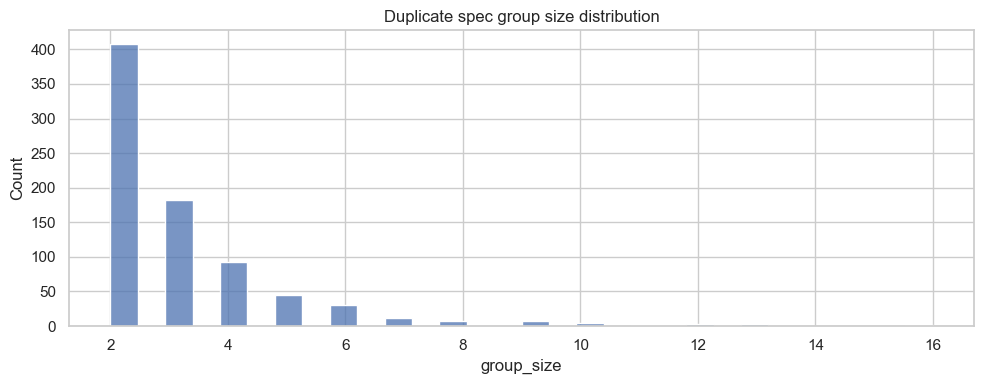

,group_size,relative_price_range
count,797.000000,797.000000
mean,3.156838,0.291134
std,1.879336,0.255680
min,2.000000,0.000000
25%,2.000000,0.106837
50%,2.000000,0.226353
75%,4.000000,0.407176
max,16.000000,2.582428


**Sample duplicate spec groups**

,shop_1_name,product_id,spec_key,brand_clean,cpu_model_clean,ram_gb_clean,storage_gb_clean,screen_size_clean,shop_2_name,shop_3_name,shop_1_price_clean,shop_2_price_clean,shop_3_price_clean,price_median,price_spread_clean_pct,flag_price_spread_warn,flag_price_spread_critical
2139,hungphuc.vn,2139,ASUS|1135G7|8.0|512.0|14.0,ASUS,1135G7,8.0,512.0,14.0,tncstore.vn,maytinhdatcang.vn,14800000.0,14990000.0,14990000.0,14990000.0,0.012675,False,False
3770,47computer.com,3770,ASUS|1135G7|8.0|512.0|14.0,ASUS,1135G7,8.0,512.0,14.0,dienmaythanhchuong.vn,viethand.com.vn,15690000.0,16200000.0,17290000.0,16200000.0,0.098765,False,False
2716,tinhocsangtao.vn,2716,ASUS|1135G7|8.0|512.0|14.0,ASUS,1135G7,8.0,512.0,14.0,vitinhminhhoang.vn,laptoptcc.com,20490000.0,16820000.0,17200000.0,17200000.0,0.213372,False,False
14,tinhocsangtao.vn,14,ASUS|1135G7|8.0|512.0|14.0,ASUS,1135G7,8.0,512.0,14.0,vitinhsangtao.vn,compro.com.vn,17300000.0,17300000.0,18900000.0,17300000.0,0.092486,False,False
1507,tinhocsangtao.vn,1507,ASUS|1135G7|8.0|512.0|14.0,ASUS,1135G7,8.0,512.0,14.0,vitinhsangtao.vn,anp.com.vn,17350000.0,17350000.0,18690000.0,17350000.0,0.077233,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3801,usalaptop.vn,3801,Lenovo|1355U|16.0|512.0|14.0,Lenovo,1355U,16.0,512.0,14.0,laptop4pro.vn,eaz.com.vn,21900000.0,24500000.0,30599000.0,24500000.0,0.355061,True,False
1205,shopee.vn,1205,Lenovo|1355U|16.0|512.0|14.0,Lenovo,1355U,16.0,512.0,14.0,ben.com.vn,kimlongcenter.com,29990000.0,31889000.0,27300000.0,29990000.0,0.153018,False,False
1790,tinhocsangtao.vn,1790,Lenovo|1355U|16.0|512.0|14.0,Lenovo,1355U,16.0,512.0,14.0,nhanhavui.com.vn,vitinhsangtao.vn,31290000.0,31890000.0,31290000.0,31290000.0,0.019175,False,False
4056,hungphuc.vn,4056,Lenovo|1355U|16.0|512.0|14.0,Lenovo,1355U,16.0,512.0,14.0,phukienlaptop.com.vn,techsys.vn,31490000.0,31590000.0,31680000.0,31590000.0,0.006015,False,False


**Nhận xét - Soft duplicate specs**

- Soft duplicate rows/log: 2,516/2516; tỷ lệ 57.4%.
- Soft duplicate specs không nhất thiết là lỗi: có thể là nhiều laptop/variants cùng cấu hình hoặc cùng cấu hình ở nhiều nguồn giá.
- Không nên drop mù. Trước modeling nên cân nhắc split train/test theo spec_key hoặc tạo group-level feature để giảm leakage/over-representation.

In [10]:
soft_dup_col = "is_soft_duplicate_spec" if "is_soft_duplicate_spec" in cleaned.columns else None
spec_col = COL["spec_key"]
soft_dup_rows = int(bool_series(cleaned, soft_dup_col).sum()) if soft_dup_col else 0
soft_dup_rate = soft_dup_rows / len(cleaned)

duplicate_group_summary = pd.DataFrame()
if spec_col:
    agg_dict = {
        "group_size": (spec_col, "size"),
        "median_price": (COL["price_median"], "median") if COL["price_median"] else (spec_col, "size"),
        "min_price": (COL["price_median"], "min") if COL["price_median"] else (spec_col, "size"),
        "max_price": (COL["price_median"], "max") if COL["price_median"] else (spec_col, "size"),
        "unique_shop_1_names": ("shop_1_name", "nunique") if "shop_1_name" in cleaned.columns else (spec_col, "size"),
        "unique_shop_2_names": ("shop_2_name", "nunique") if "shop_2_name" in cleaned.columns else (spec_col, "size"),
        "unique_shop_3_names": ("shop_3_name", "nunique") if "shop_3_name" in cleaned.columns else (spec_col, "size"),
    }
    duplicate_group_summary = cleaned.groupby(spec_col, dropna=False).agg(**agg_dict).reset_index()
    duplicate_group_summary["price_range"] = duplicate_group_summary["max_price"] - duplicate_group_summary["min_price"]
    duplicate_group_summary["relative_price_range"] = duplicate_group_summary["price_range"] / duplicate_group_summary["median_price"]
    duplicate_group_summary = duplicate_group_summary.sort_values(["group_size", "relative_price_range"], ascending=[False, False])
    top_20_soft_duplicate_groups = duplicate_group_summary[duplicate_group_summary["group_size"] > 1].head(20)
    display(pd.DataFrame([
        {"metric": "soft_duplicate_spec_rows", "actual": soft_dup_rows, "log_value": important_rule_counts_log.get("soft_duplicate_spec_rows")},
        {"metric": "soft_duplicate_spec_rate", "actual": soft_dup_rate, "log_value": None},
        {"metric": "duplicate_spec_groups_gt_1", "actual": int((duplicate_group_summary["group_size"] > 1).sum()), "log_value": None},
        {"metric": "groups_with_relative_price_range_gt_30pct", "actual": int(((duplicate_group_summary["group_size"] > 1) & (duplicate_group_summary["relative_price_range"] > 0.3)).sum()), "log_value": None},
    ]))
    display(top_20_soft_duplicate_groups)

    if PLOTTING_AVAILABLE:
        plt.figure(figsize=(10, 4))
        sns.histplot(duplicate_group_summary.loc[duplicate_group_summary["group_size"] > 1, "group_size"], bins=30)
        plt.title("Duplicate spec group size distribution")
        plt.tight_layout()
        plt.show()

    display(duplicate_group_summary.loc[duplicate_group_summary["group_size"] > 1, ["group_size", "relative_price_range"]].describe())

    sample_group_keys = top_20_soft_duplicate_groups[spec_col].head(8).tolist()
    sample_duplicate_groups = cleaned[cleaned[spec_col].isin(sample_group_keys)][audit_base_cols].sort_values([spec_col, COL["price_median"] if COL["price_median"] else spec_col])
    display(Markdown("**Sample duplicate spec groups**"))
    display(sample_duplicate_groups)
else:
    top_20_soft_duplicate_groups = pd.DataFrame()
    sample_duplicate_groups = pd.DataFrame()
    display(Markdown("No spec_key column found; cannot group soft duplicates."))

show_note(
    "Soft duplicate specs",
    [
        f"Soft duplicate rows/log: {soft_dup_rows:,}/{important_rule_counts_log.get('soft_duplicate_spec_rows')}; tỷ lệ {soft_dup_rate:.1%}.",
        "Soft duplicate specs không nhất thiết là lỗi: có thể là nhiều laptop/variants cùng cấu hình hoặc cùng cấu hình ở nhiều nguồn giá.",
        "Không nên drop mù. Trước modeling nên cân nhắc split train/test theo spec_key hoặc tạo group-level feature để giảm leakage/over-representation.",
    ],
)


### Nhận xét sau soft duplicate review

Soft duplicate không đồng nghĩa dữ liệu sai. Nó thường phản ánh nhiều sản phẩm có cấu hình gần giống nhau, nhiều biến thể SKU, hoặc nhiều listing cùng spec. Vì vậy notebook không drop các dòng này, mà báo warning để bước modeling cân nhắc split theo `spec_key`, đánh giá duplicate-aware, hoặc regularize nhóm cấu hình lặp lại.

## 8. Manual review samples - Screen size validation

,column,dtype,missing_count,missing_rate,min,max,screen_size_outlier_nulled_actual,screen_size_outlier_nulled_log
0,screen_size_clean,float64,96,0.021898,2.14,24.95,85,85


,screen_size_clean,count
0,2.14,1
1,10.00,1
2,10.50,9
3,11.60,16
4,12.00,7
5,12.30,15
6,12.40,6
7,12.50,2
8,13.00,44
9,13.30,299


,screen_size_clean,count
0,14.0,1525
1,15.6,1354
2,16.0,553
3,13.3,299
4,NaN,96
5,17.3,70
6,16.1,64
7,14.5,45
8,13.0,44
9,13.4,41


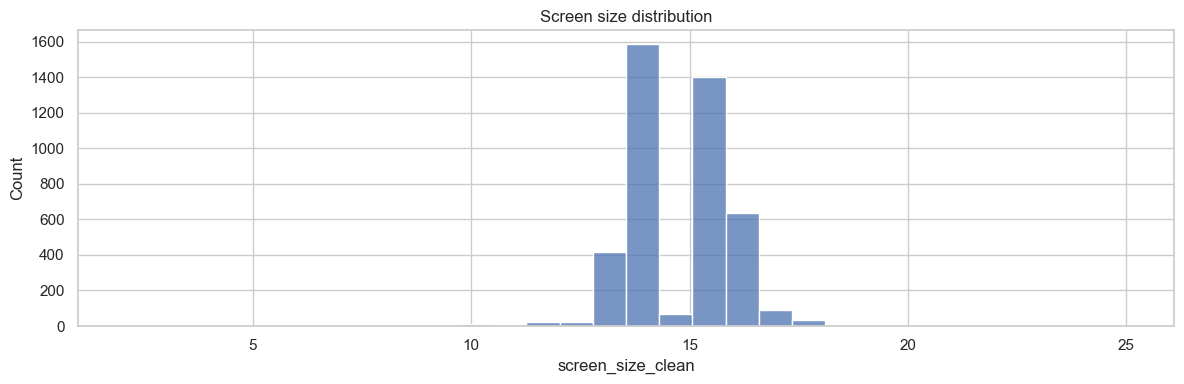

**Screen size outlier sample**

,shop_1_name,product_id,spec_key,brand_clean,cpu_model_clean,ram_gb_clean,storage_gb_clean,screen_size_clean,shop_2_name,shop_3_name,shop_1_price_clean,shop_2_price_clean,shop_3_price_clean,price_median,price_spread_clean_pct,flag_price_spread_warn,flag_price_spread_critical,Kích thước (inch),screen_size_outlier
4067,tinhocsangtao.vn,4067,Unknown|1135G7|8.0|Unknown|Unknown,Unknown,1135G7,8.0,NaN,NaN,laptoptld.com,tinhocannhon.com,21490000.0,16000000.0,19000000.0,19000000.0,0.288947,False,False,306.50,True
5,eaz.com.vn,5,Unknown|13980HX|64.0|4096.0|Unknown,Unknown,13980HX,64.0,4096.0,NaN,laptopre.vn,robo.vn,96599000.0,98190000.0,101990000.0,98190000.0,0.054904,False,False,380.00,True
3707,tinhocsangtao.vn,3707,Unknown|1355U|Unknown|Unknown|Unknown,Unknown,1355U,NaN,NaN,NaN,hungphuc.vn,shopee.vn,16990000.0,17690000.0,23890000.0,17690000.0,0.390051,True,False,358.50,True
1060,hnammobile.com,1060,Unknown|UNKNOWN|16.0|Unknown|Unknown,Unknown,UNKNOWN,16.0,NaN,NaN,hkc.vn,dienmayxanh.com,37999000.0,40900000.0,46590000.0,40900000.0,0.210049,False,False,304.10,True
481,hopthanhthinh.com,481,Unknown|11400H|8.0|Unknown|Unknown,Unknown,11400H,8.0,NaN,NaN,sp-one.vn,laptopgaming.vn,17990000.0,17990000.0,22800000.0,17990000.0,0.267371,False,False,363.40,True
4229,laptopnhatrang.com,4229,Unknown|12450H|8.0|Unknown|Unknown,Unknown,12450H,8.0,NaN,NaN,huynhlongstore.com,dienmaynguyenduc.vn,16990000.0,17900000.0,18990000.0,17900000.0,0.111732,False,False,398.00,True
455,tinhocsangtao.vn,455,Unknown|13650HX|16.0|Unknown|Unknown,Unknown,13650HX,16.0,NaN,NaN,hungphuc.vn,3bcomputer.com,30390000.0,37350000.0,28490000.0,30390000.0,0.291543,False,False,26.15,True
751,muabandienthoai24h.vn,751,Unknown|8 CORES|8.0|Unknown|Unknown,Unknown,8 CORES,8.0,NaN,NaN,akbroshop.com,tystore.vn,30500000.0,30500000.0,30990000.0,30500000.0,0.016066,False,False,304.10,True
173,shopee.vn,173,Unknown|1215U|8.0|Unknown|Unknown,Unknown,1215U,8.0,NaN,NaN,kigimart.com,anphatcomputer.vn,13190000.0,12690000.0,12850000.0,12850000.0,0.038911,False,False,359.40,True
3629,sondat.vn,3629,Unknown|1135G7|8.0|Unknown|Unknown,Unknown,1135G7,8.0,NaN,NaN,xrazer.vn,duyhungcomputer.vn,16590000.0,16990000.0,18300000.0,16990000.0,0.100647,False,False,358.50,True


**Nhận xét - Screen size**

- Rule hiện tại dùng range 0-25 inch; range này bắt outlier rõ ràng nhưng còn khá rộng cho modeling.
- Nên giữ raw/clean/group screen columns để audit, và cân nhắc practical modeling flag/range 10-18 inch hoặc screen_size_group.
- Các giá trị phổ biến cần review: 13.3, 14, 15.6, 16, 17.3.

In [11]:
screen_col = COL["screen"]
screen_outlier_col = "screen_size_outlier" if "screen_size_outlier" in cleaned.columns else None
screen_summary = pd.DataFrame([{
    "column": screen_col,
    "dtype": str(cleaned[screen_col].dtype) if screen_col else None,
    "missing_count": int(cleaned[screen_col].isna().sum()) if screen_col else np.nan,
    "missing_rate": cleaned[screen_col].isna().mean() if screen_col else np.nan,
    "min": cleaned[screen_col].min() if screen_col else np.nan,
    "max": cleaned[screen_col].max() if screen_col else np.nan,
    "screen_size_outlier_nulled_actual": int(bool_series(cleaned, screen_outlier_col).sum()) if screen_outlier_col else np.nan,
    "screen_size_outlier_nulled_log": important_rule_counts_log.get("screen_size_outlier_nulled"),
}])
display(screen_summary)
if screen_col:
    display(cleaned[screen_col].value_counts(dropna=False).sort_index().head(40).reset_index(name="count").rename(columns={"index": screen_col}))
    display(cleaned[screen_col].value_counts(dropna=False).head(20).reset_index(name="count").rename(columns={"index": screen_col}))
    if PLOTTING_AVAILABLE:
        plt.figure(figsize=(12, 4))
        sns.histplot(cleaned[screen_col], bins=30)
        plt.title("Screen size distribution")
        plt.tight_layout()
        plt.show()

display(Markdown("**Screen size outlier sample**"))
display(sample_rows(bool_series(cleaned, screen_outlier_col), audit_base_cols + [COL["screen_raw"], screen_outlier_col], n=10))

show_note(
    "Screen size",
    [
        f"Rule hiện tại dùng range {config.get('screen_min', 0)}-{config.get('screen_max', 25)} inch; range này bắt outlier rõ ràng nhưng còn khá rộng cho modeling.",
        "Nên giữ raw/clean/group screen columns để audit, và cân nhắc practical modeling flag/range 10-18 inch hoặc screen_size_group.",
        "Các giá trị phổ biến cần review: 13.3, 14, 15.6, 16, 17.3.",
    ],
)


### Nhận xét sau screen size validation

Phần screen size kiểm tra cả phân phối phổ biến lẫn giá trị ngoài range modeling thực tế. Các giá trị như 13.3, 14, 15.6, 16 và 17.3 inch thường hợp lý; các giá trị quá nhỏ hoặc quá lớn cần được flag hoặc quarantine nếu vẫn tồn tại như numeric feature hợp lệ. Plot giúp phát hiện lỗi parse inch hoặc nhầm đơn vị.

## 9. Manual review samples - RAM validation

,column,dtype,missing_count,missing_rate,min,max,ram_capacity_outlier_nulled_actual,ram_capacity_outlier_nulled_log
0,ram_gb_clean,float64,23,0.005246,2.0,192.0,2,2


,ram_gb_clean,count
0,2.0,6
1,4.0,595
2,5.0,3
3,6.0,1
4,8.0,1448
5,12.0,9
6,15.0,2
7,16.0,1648
8,18.0,2
9,19.0,1


,ram_gb_clean,n,median_price
0,2.0,6,5418500.0
1,4.0,595,12200000.0
2,5.0,3,31790000.0
3,6.0,1,17200000.0
4,8.0,1448,17799000.0
5,12.0,9,18350000.0
6,15.0,2,24594500.0
7,16.0,1648,25194500.0
8,18.0,2,34344500.0
9,19.0,1,43890000.0


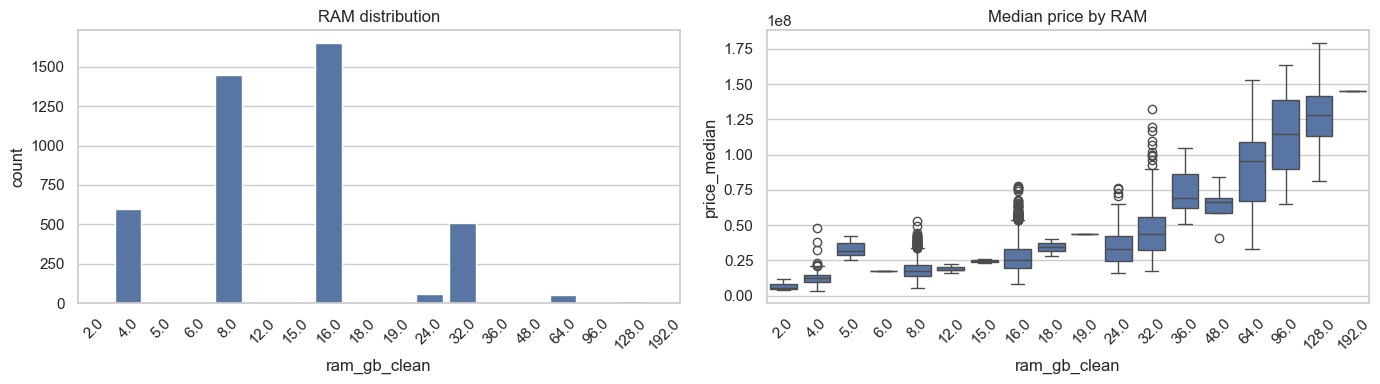

**RAM outlier sample**

,shop_1_name,product_id,spec_key,brand_clean,cpu_model_clean,ram_gb_clean,storage_gb_clean,screen_size_clean,shop_2_name,shop_3_name,shop_1_price_clean,shop_2_price_clean,shop_3_price_clean,price_median,price_spread_clean_pct,flag_price_spread_warn,flag_price_spread_critical,Dung lượng RAM,ram_capacity_outlier
1762,dienmayxanh.com,1762,Apple|8‑CORE CPU|Unknown|Unknown|15.6,Apple,8‑CORE CPU,NaN,NaN,15.6,mac24h.vn,eaz.com.vn,35090000.0,36500000.0,40699000.0,36500000.0,0.153671,False,False,512.0,True
2423,hkc.vn,2423,HP|8845HS|Unknown|512.0|16.1,HP,8845HS,NaN,512.0,16.1,ben.com.vn,dinhvangcomputer.vn,33200000.0,39318000.0,27890000.0,33200000.0,0.344217,True,False,5600.0,True


**Nhận xét - RAM**

- RAM outlier actual/log: 2/2.
- RAM numeric đủ phù hợp cho modeling; nên cân nhắc bucket/tier và flag high-RAM workstation/gaming nếu phân phối đuôi cao ảnh hưởng model.
- Giữ RAM missing/Unknown thay vì drop dòng.

In [12]:
ram_col = COL["ram"]
ram_outlier_col = "ram_capacity_outlier" if "ram_capacity_outlier" in cleaned.columns else None
ram_summary = pd.DataFrame([{
    "column": ram_col,
    "dtype": str(cleaned[ram_col].dtype) if ram_col else None,
    "missing_count": int(cleaned[ram_col].isna().sum()) if ram_col else np.nan,
    "missing_rate": cleaned[ram_col].isna().mean() if ram_col else np.nan,
    "min": cleaned[ram_col].min() if ram_col else np.nan,
    "max": cleaned[ram_col].max() if ram_col else np.nan,
    "ram_capacity_outlier_nulled_actual": int(bool_series(cleaned, ram_outlier_col).sum()) if ram_outlier_col else np.nan,
    "ram_capacity_outlier_nulled_log": important_rule_counts_log.get("ram_capacity_outlier_nulled"),
}])
display(ram_summary)
if ram_col:
    display(cleaned[ram_col].value_counts(dropna=False).sort_index().reset_index(name="count").rename(columns={"index": ram_col}))
    if COL["price_median"]:
        ram_price = cleaned.groupby(ram_col, dropna=False).agg(n=(ram_col, "size"), median_price=(COL["price_median"], "median")).reset_index().sort_values(ram_col)
        display(ram_price)
    if PLOTTING_AVAILABLE:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        sns.countplot(data=cleaned, x=ram_col, ax=axes[0], order=sorted(cleaned[ram_col].dropna().unique()))
        axes[0].tick_params(axis="x", rotation=45)
        axes[0].set_title("RAM distribution")
        if COL["price_median"]:
            sns.boxplot(data=cleaned, x=ram_col, y=COL["price_median"], ax=axes[1], order=sorted(cleaned[ram_col].dropna().unique()))
            axes[1].tick_params(axis="x", rotation=45)
            axes[1].set_title("Median price by RAM")
        plt.tight_layout()
        plt.show()

display(Markdown("**RAM outlier sample**"))
display(sample_rows(bool_series(cleaned, ram_outlier_col), audit_base_cols + [COL["ram_raw"], ram_outlier_col], n=10))

show_note(
    "RAM",
    [
        f"RAM outlier actual/log: {int(bool_series(cleaned, ram_outlier_col).sum()) if ram_outlier_col else 0}/{important_rule_counts_log.get('ram_capacity_outlier_nulled')}.",
        "RAM numeric đủ phù hợp cho modeling; nên cân nhắc bucket/tier và flag high-RAM workstation/gaming nếu phân phối đuôi cao ảnh hưởng model.",
        "Giữ RAM missing/Unknown thay vì drop dòng.",
    ],
)


### Nhận xét sau RAM validation

RAM là feature dự báo giá quan trọng nên range check phải nghiêm hơn audit thông thường. Phân phối countplot và boxplot theo giá giúp xem RAM có quan hệ hợp lý với target hay không. Giá trị ngoài khoảng 2-128GB nếu không được flag/null sẽ bị xem là không an toàn cho modeling-ready.

## 10. Manual review samples - Storage validation

,column,dtype,missing_count,missing_rate,min,max,storage_gb_outlier_actual
0,storage_gb_clean,float64,225,0.051323,16.0,8192.0,0


,storage_gb_clean,count
0,512.0,2201
1,1024.0,1036
2,256.0,607
3,NaN,225
4,500.0,110
5,2048.0,71
6,128.0,51
7,1152.0,36
8,4096.0,12
9,1280.0,6


,storage_type_clean,count
0,SSD,3702
1,HDD,402
2,Unknown,222
3,SSD + HDD,57
4,Other,1


,storage_gb_clean,n,median_price
9,512.0,2201,21190000.0
13,1024.0,1036,30990000.0
6,256.0,607,15480000.0
26,NaN,225,19690000.0
8,500.0,110,11248500.0
21,2048.0,71,77490000.0
4,128.0,51,11940000.0
18,1152.0,36,23975000.0
23,4096.0,12,109294500.0
19,1280.0,6,29340000.0


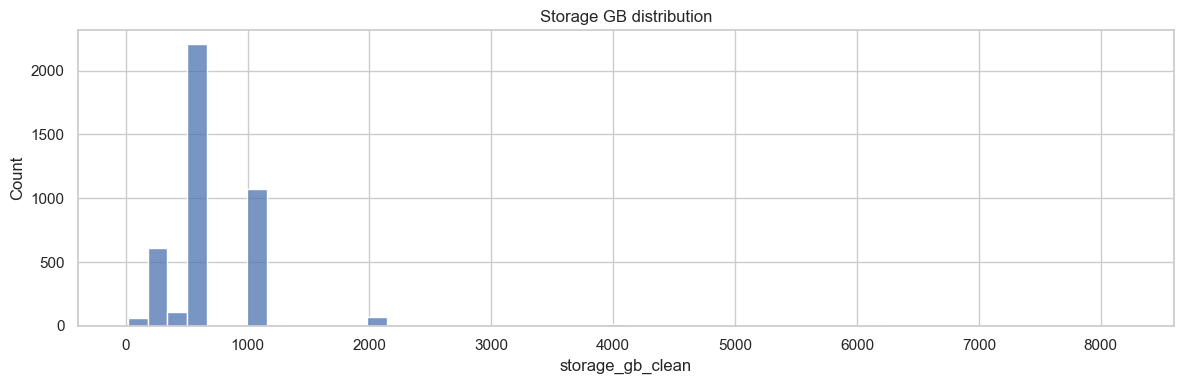

**Nhận xét - Storage**

- Kiểm tra min/max/common values để bắt lỗi TB/GB conversion; các mức 256/512/1024GB thường nên chiếm tỷ trọng lớn.
- Storage numeric nên được bucket/tier ở feature engineering, đồng thời giữ storage type nếu đủ sạch.
- Không thấy storage outlier bị null trong log hiện tại; missing storage vẫn cần nhóm Unknown/flag.

In [13]:
storage_col = COL["storage"]
storage_outlier_col = "storage_gb_outlier" if "storage_gb_outlier" in cleaned.columns else None
storage_summary = pd.DataFrame([{
    "column": storage_col,
    "dtype": str(cleaned[storage_col].dtype) if storage_col else None,
    "missing_count": int(cleaned[storage_col].isna().sum()) if storage_col else np.nan,
    "missing_rate": cleaned[storage_col].isna().mean() if storage_col else np.nan,
    "min": cleaned[storage_col].min() if storage_col else np.nan,
    "max": cleaned[storage_col].max() if storage_col else np.nan,
    "storage_gb_outlier_actual": int(bool_series(cleaned, storage_outlier_col).sum()) if storage_outlier_col else np.nan,
}])
display(storage_summary)
if storage_col:
    display(cleaned[storage_col].value_counts(dropna=False).head(30).reset_index(name="count").rename(columns={"index": storage_col}))
    if COL["storage_type"]:
        display(cleaned[COL["storage_type"]].value_counts(dropna=False).head(20).reset_index(name="count").rename(columns={"index": COL["storage_type"]}))
    if COL["price_median"]:
        storage_price = cleaned.groupby(storage_col, dropna=False).agg(n=(storage_col, "size"), median_price=(COL["price_median"], "median")).reset_index().sort_values("n", ascending=False).head(30)
        display(storage_price)
    if PLOTTING_AVAILABLE:
        plt.figure(figsize=(12, 4))
        sns.histplot(cleaned[storage_col], bins=50)
        plt.title("Storage GB distribution")
        plt.tight_layout()
        plt.show()

show_note(
    "Storage",
    [
        "Kiểm tra min/max/common values để bắt lỗi TB/GB conversion; các mức 256/512/1024GB thường nên chiếm tỷ trọng lớn.",
        "Storage numeric nên được bucket/tier ở feature engineering, đồng thời giữ storage type nếu đủ sạch.",
        "Không thấy storage outlier bị null trong log hiện tại; missing storage vẫn cần nhóm Unknown/flag.",
    ],
)


### Nhận xét sau storage validation

Storage cần kiểm tra kỹ lỗi quy đổi GB/TB vì sai số ở cột này có thể làm model học quan hệ giá sai. Các mức 256GB, 512GB, 1024GB thường là nhóm chính; giá trị quá thấp như 16GB cần được flag hoặc quarantine nếu không phải là dữ liệu đã xử lý. Bảng theo storage type giúp phân biệt dung lượng và loại ổ, tránh trộn HDD/SSD như cùng một tín hiệu.

## 11. Audit-only diagnostics - Brand / Model / Category validation

In [14]:
brand_col = COL["brand"]
brand_grouped_col = COL["brand_grouped"]
model_col = COL["model"]

brand_counts = cleaned[brand_col].value_counts(dropna=False).reset_index(name="count").rename(columns={"index": brand_col}) if brand_col else pd.DataFrame()
brand_price = (
    cleaned.groupby(brand_col, dropna=False)
    .agg(n=(brand_col, "size"), median_price=(COL["price_median"], "median"))
    .reset_index()
    .sort_values("median_price", ascending=False)
) if brand_col and COL["price_median"] else pd.DataFrame()
unknown_brand_mask = cleaned[brand_col].astype(str).str.lower().isin(["unknown", "other", "nan"]) if brand_col else pd.Series(False, index=cleaned.index)
rare_brand_col = "brand_is_rare" if "brand_is_rare" in cleaned.columns else None
rare_brand_list = brand_counts[brand_counts["count"] < config.get("rare_count_threshold", 30)] if not brand_counts.empty else pd.DataFrame()

display(Markdown("**Top brand counts**"))
display(brand_counts.head(30))
display(Markdown("**Rare brand list**"))
display(rare_brand_list)
display(Markdown("**Median price by brand**"))
display(brand_price.head(30))

if model_col:
    display(Markdown("**Top model/product line counts**"))
    display(cleaned[model_col].value_counts(dropna=False).head(30).reset_index(name="count").rename(columns={"index": model_col}))

display(Markdown("**Unknown/Other brand samples**"))
display(sample_rows(unknown_brand_mask, audit_base_cols + [COL["brand_raw"], brand_grouped_col], n=10))

if brand_col and screen_col:
    brand_screen = cleaned.groupby([brand_col, screen_col], dropna=False).agg(n=(brand_col, "size"), median_price=(COL["price_median"], "median") if COL["price_median"] else (brand_col, "size")).reset_index()
    low_brand_screen = brand_screen[brand_screen["n"] < config.get("min_brand_screen_cell_n", 10)].sort_values("n")
    display(Markdown("**Low-count brand-screen cells**"))
    display(low_brand_screen.head(30))

show_note(
    "Brand/model/category",
    [
        "brand_clean/brand_grouped đủ dùng cho modeling nếu rare brands được xử lý ở feature engineering.",
        "Rare brands nên gộp Other ở feature engineering hơn là sửa cleaning nếu alias không chắc chắn.",
        "Nếu Unknown brand samples cho thấy alias rõ ràng bị miss, đó là candidate quay lại pipeline để bổ sung mapping.",
    ],
)


**Top brand counts**

,brand_clean,count
0,HP,832
1,Dell,805
2,Lenovo,802
3,ASUS,801
4,Acer,314
5,MSI,275
6,Unknown,180
7,Apple,146
8,Microsoft,89
9,Gigabyte,56


**Rare brand list**

,brand_clean,count
11,Samsung,14
12,Surface,14
13,Toshiba,4
14,Xiaomi,3
15,Vaio,3
16,Avita,3
17,Masstel,2
18,Aorus,2
19,Mechrevo,1
20,Intel,1


**Median price by brand**

...

**Unknown/Other brand samples**

,shop_1_name,product_id,spec_key,brand_clean,cpu_model_clean,ram_gb_clean,storage_gb_clean,screen_size_clean,shop_2_name,shop_3_name,shop_1_price_clean,shop_2_price_clean,shop_3_price_clean,price_median,price_spread_clean_pct,flag_price_spread_warn,flag_price_spread_critical,Hãng sản xuất,brand_grouped
414,cameranhapkhau.com,414,Unknown|8565U|8.0|Unknown|14.0,Unknown,8565U,8.0,NaN,14.0,laptopfull.com,laptop36.vn,25470000.0,22790000.0,25450000.0,25450000.0,0.105305,False,False,NaN,Unknown
789,hkc.vn,789,Unknown|11980HK|64.0|2048.0|Unknown,Unknown,11980HK,64.0,2048.0,NaN,eaz.com.vn,mylook.vn,99990000.0,104900000.0,111089000.0,104900000.0,0.105806,False,False,NaN,Unknown
3680,cellphones.com.vn,3680,Unknown|1340P|16.0|Unknown|16.0,Unknown,1340P,16.0,NaN,16.0,shopee.vn,hkc.vn,13990000.0,16400000.0,18550000.0,16400000.0,0.278049,False,False,NaN,Unknown
1858,masta.vn,1858,Unknown|UNKNOWN|8.0|Unknown|Unknown,Unknown,UNKNOWN,8.0,NaN,NaN,mobi9.vn,muabandienthoai24h.vn,37500000.0,38900000.0,42700000.0,38900000.0,0.133676,False,False,NaN,Unknown
3467,eaz.com.vn,3467,Unknown|1135G7|8.0|Unknown|14.0,Unknown,1135G7,8.0,NaN,14.0,hugotech.vn,songphuong.vn,30799000.0,33000000.0,35490000.0,33000000.0,0.142152,False,False,NaN,Unknown
285,laptop15.vn,285,Unknown|1360P|16.0|Unknown|16.0,Unknown,1360P,16.0,NaN,16.0,laptoptcc.com,ngocnguyen.vn,16000000.0,18900000.0,18990000.0,18900000.0,0.158201,False,False,NaN,Unknown
465,tinhochungphat.com,465,Unknown|1355U|16.0|Unknown|Unknown,Unknown,1355U,16.0,NaN,NaN,huecomputer.vn,vitinhkiengiang.com,14988000.0,14990000.0,15390000.0,14990000.0,0.026818,False,False,NaN,Unknown
1612,saleslaptop.vn,1612,Unknown|4030U|4.0|500.0|14.0,Unknown,4030U,4.0,500.0,14.0,phucanshop.com,4tcomputer.vn,4500000.0,8499000.0,9490000.0,8499000.0,0.587128,True,True,NaN,Unknown
2795,laptop15.vn,2795,Unknown|7730U|8.0|Unknown|Unknown,Unknown,7730U,8.0,NaN,NaN,truongthinh.top,laptopworld.vn,8500000.0,11190000.0,11990000.0,11190000.0,0.311886,True,False,NaN,Unknown
2858,hungphuc.vn,2858,Unknown|12450H|8.0|Unknown|Unknown,Unknown,12450H,8.0,NaN,NaN,hkc.vn,laptop15.vn,20590000.0,21100000.0,13700000.0,20590000.0,0.359398,True,False,NaN,Unknown


**Low-count brand-screen cells**

,brand_clean,screen_size_clean,n,median_price
78,Lenovo,12.50,1,34890000.0
61,HP,12.00,1,38000000.0
69,Intel,15.60,1,19990000.0
70,LG,13.30,1,26400000.0
75,Lenovo,2.14,1,67790000.0
77,Lenovo,12.30,1,17990000.0
144,Xiaomi,15.60,1,11990000.0
84,Lenovo,15.00,1,16590000.0
91,MSI,13.40,1,38990000.0
98,Masstel,11.60,1,5990000.0


**Nhận xét - Brand/model/category**

- brand_clean/brand_grouped đủ dùng cho modeling nếu rare brands được xử lý ở feature engineering.
- Rare brands nên gộp Other ở feature engineering hơn là sửa cleaning nếu alias không chắc chắn.
- Nếu Unknown brand samples cho thấy alias rõ ràng bị miss, đó là candidate quay lại pipeline để bổ sung mapping.

### Nhận xét sau brand/model/category validation

Các bảng brand và model cho biết mức độ sạch của nhóm category sau parsing. Unknown/Other hoặc brand hiếm không làm fail validation, nhưng cần được encode/gộp cẩn thận ở feature engineering để tránh category quá sparse. Bảng median price by brand chỉ là diagnostic, không nên dùng trực tiếp để tạo feature từ target.

## 12. Audit-only diagnostics - Shop name validation

In [15]:
shop_coverage_rows = []
for price_col, clean_col, name_col, rel_col in zip(price_cols, price_clean_cols, shop_name_cols, relative_outlier_cols):
    shop_coverage_rows.append({
        "price_slot": price_col,
        "shop_name_col": name_col,
        "shop_name_missing": int(cleaned[name_col].isna().sum()),
        "raw_price_missing": int(cleaned[price_col].isna().sum()),
        "clean_price_missing": int(cleaned[clean_col].isna().sum()),
        "relative_outlier_cells": int(bool_series(cleaned, rel_col).sum()),
    })
shop_coverage_table = pd.DataFrame(shop_coverage_rows)
display(shop_coverage_table)

shop_long_parts = []
for price_col, clean_col, name_col, rel_col, dom_col in zip(price_cols, price_clean_cols, shop_name_cols, relative_outlier_cols, domain_outlier_cols):
    tmp = cleaned[[name_col, price_col, clean_col, rel_col, dom_col, COL["price_median"]]].copy()
    tmp.columns = ["shop_name", "raw_price", "clean_price", "relative_outlier", "domain_outlier", "price_median"]
    tmp["slot"] = price_col
    tmp["relative_deviation_from_median"] = (tmp["clean_price"] - tmp["price_median"]) / tmp["price_median"]
    shop_long_parts.append(tmp)
shop_long = pd.concat(shop_long_parts, ignore_index=True) if shop_long_parts else pd.DataFrame()

if not shop_long.empty:
    top_shop_names = shop_long["shop_name"].value_counts(dropna=False).head(30).reset_index(name="count").rename(columns={"index": "shop_name"})
    shop_reliability_summary = (
        shop_long.groupby("shop_name", dropna=False)
        .agg(
            n=("shop_name", "size"),
            clean_price_missing_rate=("clean_price", lambda x: x.isna().mean()),
            relative_outlier_rate=("relative_outlier", lambda x: bool_series(pd.DataFrame({"x": x}), "x").mean()),
            domain_outlier_rate=("domain_outlier", lambda x: bool_series(pd.DataFrame({"x": x}), "x").mean()),
            avg_deviation_from_median=("relative_deviation_from_median", "mean"),
            median_abs_deviation_from_median=("relative_deviation_from_median", lambda x: x.abs().median()),
        )
        .reset_index()
        .sort_values(["relative_outlier_rate", "median_abs_deviation_from_median", "n"], ascending=[False, False, False])
    )
    display(Markdown("**Top shop names**"))
    display(top_shop_names)
    display(Markdown("**Shop reliability summary**"))
    display(shop_reliability_summary.head(40))

show_note(
    "Shop names",
    [
        "shop_1/2/3 là price slots chứ không phải fixed shops; phân tích shop reliability phải dùng shop_name thật ở long format.",
        "Shop name có thể hữu ích cho diagnostics/source quality, nhưng dùng làm feature có thể làm model học nguồn/crawl hơn là giá trị sản phẩm.",
        "Nếu target là price_median, shop-specific price columns nên audit-only; shop reliability flags có thể giữ cho phân tích nhạy cảm.",
    ],
)


,price_slot,shop_name_col,shop_name_missing,raw_price_missing,clean_price_missing,relative_outlier_cells
0,shop_1_price,shop_1_name,0,0,33,32
1,shop_2_price,shop_2_name,0,0,8,8
2,shop_3_price,shop_3_name,2,2,18,13


**Top shop names**

,shop_name,count
0,eaz.com.vn,1064
1,compro.com.vn,768
2,tinhocsangtao.vn,468
3,hungphuc.vn,356
4,shopee.vn,341
5,hkc.vn,320
6,vitinhmanhphat.com,302
7,dienmayxanh.com,285
8,cellphones.com.vn,277
9,ben.com.vn,269


**Shop reliability summary**

,shop_name,n,clean_price_missing_rate,relative_outlier_rate,domain_outlier_rate,avg_deviation_from_median,median_abs_deviation_from_median
123,duchuy365store.com,1,1.000000,1.000000,0.000000,NaN,NaN
282,laptopcudaklak.com,1,1.000000,1.000000,0.000000,NaN,NaN
412,maytinhbaclieu.com.vn,1,1.000000,1.000000,0.000000,NaN,NaN
565,phucquangcomputer.com,1,1.000000,1.000000,0.000000,NaN,NaN
344,laptopthunguyen.com,3,0.666667,0.666667,0.000000,0.181818,0.181818
280,laptopbinhduongvtc.vn,9,0.444444,0.444444,0.000000,-0.131795,0.037536
256,lap24h.vn,5,0.400000,0.400000,0.000000,-0.203592,0.132653
783,vitinhgiaphuc.com,3,0.333333,0.333333,0.000000,0.439834,0.439834
794,vitinhtaynguyen.com,3,0.333333,0.333333,0.000000,-0.093333,0.122052
268,laptop36.vn,13,0.307692,0.307692,0.000000,-0.048597,0.010611


**Nhận xét - Shop names**

- shop_1/2/3 là price slots chứ không phải fixed shops; phân tích shop reliability phải dùng shop_name thật ở long format.
- Shop name có thể hữu ích cho diagnostics/source quality, nhưng dùng làm feature có thể làm model học nguồn/crawl hơn là giá trị sản phẩm.
- Nếu target là price_median, shop-specific price columns nên audit-only; shop reliability flags có thể giữ cho phân tích nhạy cảm.

### Nhận xét sau shop name validation

Shop name và shop reliability là thông tin nguồn dữ liệu, không phải đặc tính sản phẩm. Các bảng này hữu ích để audit nguồn nào thường thiếu giá hoặc bị outlier, nhưng đưa shop/source vào model có thể khiến model học đặc điểm crawl/nguồn thay vì học cấu hình laptop.

## 13. Non-blocking warning review - Low-count categories / interaction cells

In [16]:
rare_count_threshold = config.get("rare_count_threshold", 30)
min_brand_screen_cell_n = config.get("min_brand_screen_cell_n", 10)
min_interaction_cell_n = config.get("min_interaction_cell_n", 20)

low_count_tables = {}
if brand_col:
    low_count_tables["rare_brand"] = cleaned.groupby(brand_col, dropna=False).size().reset_index(name="n").query("n < @rare_count_threshold").sort_values("n")
if screen_col:
    low_count_tables["rare_screen_size"] = cleaned.groupby(screen_col, dropna=False).size().reset_index(name="n").query("n < @rare_count_threshold").sort_values("n")
if ram_col and storage_col:
    low_count_tables["rare_ram_storage_combo"] = cleaned.groupby([ram_col, storage_col], dropna=False).size().reset_index(name="n").query("n < @min_interaction_cell_n").sort_values("n")
if brand_col and screen_col:
    low_count_tables["rare_brand_screen_cell"] = cleaned.groupby([brand_col, screen_col], dropna=False).size().reset_index(name="n").query("n < @min_brand_screen_cell_n").sort_values("n")
if "cpu_tier" in cleaned.columns and ram_col:
    low_count_tables["rare_cpu_ram_cell"] = cleaned.groupby(["cpu_tier", ram_col], dropna=False).size().reset_index(name="n").query("n < @min_interaction_cell_n").sort_values("n")
if "gpu_tier_v2" in cleaned.columns and ram_col:
    low_count_tables["rare_gpu_ram_cell"] = cleaned.groupby(["gpu_tier_v2", ram_col], dropna=False).size().reset_index(name="n").query("n < @min_interaction_cell_n").sort_values("n")

low_count_summary = pd.DataFrame([
    {"group_type": k, "n_groups_below_threshold": len(v)}
    for k, v in low_count_tables.items()
])
display(low_count_summary)
for name, table in low_count_tables.items():
    display(Markdown(f"**{name}**"))
    display(table.head(30))

show_note(
    "Low-count categories",
    [
        f"Thresholds: rare_count_threshold={rare_count_threshold}, min_brand_screen_cell_n={min_brand_screen_cell_n}, min_interaction_cell_n={min_interaction_cell_n}.",
        "Low-count groups nên được merge/regularize ở feature engineering, trừ các nhóm hiếm nhưng có ý nghĩa kinh doanh rõ.",
        "Interaction cells quá nhỏ không nên dùng để kết luận EDA mạnh hoặc tạo feature sparse không kiểm soát.",
    ],
)


,group_type,n_groups_below_threshold
0,rare_brand,14
1,rare_screen_size,27
2,rare_ram_storage_combo,65
3,rare_brand_screen_cell,98
4,rare_cpu_ram_cell,32
5,rare_gpu_ram_cell,46


**rare_brand**

,brand_clean,n
5,Chuwi,1
7,Fujitsu,1
10,Intel,1
15,Mechrevo,1
17,Razer,1
24,Xpg,1
2,Aorus,2
14,Masstel,2
4,Avita,3
22,Vaio,3


**rare_screen_size**

,screen_size_clean,n
0,2.14,1
35,19.87,1
34,18.90,1
25,15.95,1
23,15.50,1
37,22.70,1
38,24.95,1
1,10.00,1
7,12.50,2
36,20.77,2


...

**rare_cpu_ram_cell**

,cpu_tier,ram_gb_clean,n
17,Mid-range,5.0,1
38,Upper-mid,12.0,1
29,Unknown,18.0,1
9,High-end,96.0,1
42,Upper-mid,19.0,1
11,High-end,192.0,1
48,Upper-mid,96.0,1
25,Unknown,2.0,1
15,Low-end,NaN,1
18,Mid-range,6.0,1


**rare_gpu_ram_cell**

,gpu_tier_v2,ram_gb_clean,n
2,AMD Radeon,15.0,1
66,RTX 5000,192.0,1
65,RTX 5000,96.0,1
54,RTX 4000,15.0,1
50,Other RTX,96.0,1
41,Other GPU,64.0,1
31,Intel Integrated,48.0,1
27,Intel Integrated,12.0,1
21,GTX,6.0,1
19,Apple GPU,NaN,1


**Nhận xét - Low-count categories**

- Thresholds: rare_count_threshold=30, min_brand_screen_cell_n=10, min_interaction_cell_n=20.
- Low-count groups nên được merge/regularize ở feature engineering, trừ các nhóm hiếm nhưng có ý nghĩa kinh doanh rõ.
- Interaction cells quá nhỏ không nên dùng để kết luận EDA mạnh hoặc tạo feature sparse không kiểm soát.

### Nhận xét sau low-count interaction cells

Low-count cells cho thấy các tổ hợp brand-screen, CPU-RAM hoặc GPU-RAM có quá ít quan sát để model tổng quát ổn định. Đây là warning không chặn vì có thể xử lý ở feature engineering bằng grouping, rare-category encoding hoặc regularization. Không nên drop dòng chỉ vì rơi vào nhóm ít quan sát.

## 14. Model-safe contract, quarantine, and validation report

In [17]:
# -----------------------------------------------------------------------------
# Model-safe contract
# -----------------------------------------------------------------------------
target_col = "price_median"

# Requested contract groups. Only existing columns are used downstream, so optional
# schema differences are reported without failing the notebook by themselves.
target_cols = ["price_median"]
direct_price_cols = [
    "price_min_clean",
    "price_max_clean",
    "price_min_raw",
    "price_max_raw",
    "price_mean_clean",
    "price_mean_raw",
]

price_derived_qc_cols = [
    "price_spread",
    "price_spread_ratio",
    "flag_price_spread_warn",
    "flag_price_spread_critical",
    "n_prices_raw",
    "n_prices_clean",
]

# Dataset-specific aliases/price columns that are also direct price leakage for a
# price_median prediction task.
dataset_direct_price_cols = price_cols + price_domain_cols + price_clean_cols + [
    "price_row_median_domain",
    "log_price_median",
]
dataset_price_derived_qc_cols = existing([COL["price_spread"]])

leakage_cols = sorted(set(existing(target_cols + direct_price_cols + price_derived_qc_cols + dataset_direct_price_cols + dataset_price_derived_qc_cols)))

metadata_cols = [
    "url",
    "title",
    "raw_title",
    "product_id",
    "source",
    "shop_name",
]
dataset_metadata_cols = existing([COL["product_id"], COL["product_name"], COL["spec_key"]] + shop_name_cols)
metadata_cols_existing = sorted(set(existing(metadata_cols) + dataset_metadata_cols))

qc_only_cols = [
    "needs_review",
    "manual_review_reason",
    "soft_duplicate_group",
    "flag_soft_duplicate",
]
dataset_qc_only_cols = existing(
    qc_only_cols
    + [
        "is_soft_duplicate_spec",
        "screen_size_outlier",
        "ram_capacity_outlier",
        "storage_gb_outlier",
        "low_count_brand_screen_cell",
        "low_count_cpu_ram_cell",
        "low_count_gpu_ram_cell",
        "brand_is_rare",
    ]
    + domain_outlier_cols
    + relative_outlier_cols
)
qc_only_cols_existing = sorted(set(dataset_qc_only_cols))

free_text_raw_cols = sorted(set(existing([
    "Hãng sản xuất",
    "Công nghệ CPU",
    "Loại CPU",
    "Dung lượng RAM",
    "Loại RAM",
    "Loại ổ cứng",
    "Dung lượng ổ cứng (GB)",
    "Đồ họa đã làm sạch",
    "Kích thước (inch)",
    "title",
    "raw_title",
    "product_name",
    "name",
    "Tên sản phẩm",
])))

# Conservative tabular feature contract: cleaned spec fields only. Raw text, IDs,
# target/direct price, price-derived QC and audit-only flags stay out by default.
candidate_feature_cols = existing([
    COL["brand"],
    COL["brand_grouped"],
    COL["ram"],
    "ram_tier_clean",
    "ram_type_clean",
    COL["storage"],
    COL["storage_type"],
    "storage_tier_clean",
    COL["screen"],
    COL["screen_group"],
    "cpu_brand",
    "cpu_tier",
    "cpu_model_clean",
    "gpu_brand",
    "gpu_tier_v2",
    "high_end_config_flag",
])

excluded_cols = set([target_col]) | set(leakage_cols) | set(metadata_cols_existing) | set(qc_only_cols_existing) | set(free_text_raw_cols)
feature_cols = [c for c in candidate_feature_cols if c in cleaned.columns and c not in excluded_cols]

# -----------------------------------------------------------------------------
# Quarantine rows that are structurally unusable for modeling.
# -----------------------------------------------------------------------------
if target_col in cleaned.columns:
    missing_target_mask = cleaned[target_col].isna()
else:
    missing_target_mask = pd.Series(True, index=cleaned.index)

no_valid_clean_price_mask = cleaned["n_prices_clean"].eq(0) if "n_prices_clean" in cleaned.columns else pd.Series(False, index=cleaned.index)

range_specs = {
    "ram_gb_clean": {"min": 2, "max": 128, "flag": "ram_capacity_outlier", "check_name": "impossible RAM values not handled"},
    "storage_gb_clean": {"min": 32, "max": 8192, "flag": "storage_gb_outlier", "check_name": "impossible storage values not handled"},
    "screen_size_clean": {"min": 10, "max": 20, "flag": "screen_size_outlier", "check_name": "impossible screen size values not handled"},
}

range_results = {}
unhandled_impossible_masks = []
for col, spec in range_specs.items():
    if col not in cleaned.columns:
        range_results[col] = {
            "outside_mask": pd.Series(False, index=cleaned.index),
            "flagged_mask": pd.Series(False, index=cleaned.index),
            "unhandled_mask": pd.Series(False, index=cleaned.index),
            "outside_n": 0,
            "flagged_n": 0,
            "unhandled_n": 0,
            "missing_col": True,
        }
        continue
    numeric = pd.to_numeric(cleaned[col], errors="coerce")
    outside = numeric.notna() & ~numeric.between(spec["min"], spec["max"])
    flagged = bool_series(cleaned, spec["flag"]) if spec["flag"] in cleaned.columns else pd.Series(False, index=cleaned.index)
    unhandled = outside & ~flagged
    range_results[col] = {
        "outside_mask": outside,
        "flagged_mask": flagged,
        "unhandled_mask": unhandled,
        "outside_n": int(outside.sum()),
        "flagged_n": int((outside & flagged).sum()),
        "unhandled_n": int(unhandled.sum()),
        "missing_col": False,
    }
    unhandled_impossible_masks.append(unhandled)

unhandled_impossible_mask = np.logical_or.reduce(unhandled_impossible_masks) if unhandled_impossible_masks else pd.Series(False, index=cleaned.index)
unhandled_impossible_mask = pd.Series(unhandled_impossible_mask, index=cleaned.index)

quarantine_reason_parts = []
quarantine_reason_parts.append(pd.Series(np.where(missing_target_mask, "missing price_median", ""), index=cleaned.index))
quarantine_reason_parts.append(pd.Series(np.where(no_valid_clean_price_mask, "no valid cleaned price source", ""), index=cleaned.index))
for col, result in range_results.items():
    quarantine_reason_parts.append(pd.Series(np.where(result["unhandled_mask"], f"unhandled impossible {col}", ""), index=cleaned.index))

quarantine_reason = pd.Series("", index=cleaned.index, dtype="object")
for part in quarantine_reason_parts:
    quarantine_reason = ["; ".join([x for x in [a, b] if x]) for a, b in zip(quarantine_reason, part)]
quarantine_reason = pd.Series(quarantine_reason, index=cleaned.index)

quarantine_mask = missing_target_mask | no_valid_clean_price_mask | unhandled_impossible_mask
quarantine_missing_target = cleaned.loc[missing_target_mask].copy()
quarantine = cleaned.loc[quarantine_mask].copy()
quarantine["quarantine_reason"] = quarantine_reason.loc[quarantine_mask].values
modeling_ready = cleaned.loc[~quarantine_mask].copy()

# Hard model-contract assertions. Convert assertion errors into validation rows and
# final FAIL status instead of crashing the notebook before export.
contract_failures = []
try:
    assert target_col not in feature_cols
except AssertionError:
    contract_failures.append("target_col appears in feature_cols")
try:
    assert not set(feature_cols) & set(leakage_cols)
except AssertionError:
    contract_failures.append(f"leakage columns in feature_cols: {sorted(set(feature_cols) & set(leakage_cols))}")
try:
    assert not set(feature_cols) & set(metadata_cols_existing)
except AssertionError:
    contract_failures.append(f"metadata columns in feature_cols: {sorted(set(feature_cols) & set(metadata_cols_existing))}")
try:
    assert len(feature_cols) > 0
except AssertionError:
    contract_failures.append("feature_cols is empty")

modeling_ready_missing_target = int(modeling_ready[target_col].isna().sum()) if target_col in modeling_ready.columns else len(modeling_ready)
manual_count = int(issue_status_counts_log.get("needs_manual_review", (action_plan["resolution_status"] == "needs_manual_review").sum()))
partial_count = int(issue_status_counts_log.get("partially_resolved", (action_plan["resolution_status"] == "partially_resolved").sum()))

# -----------------------------------------------------------------------------
# Normalized validation report
# -----------------------------------------------------------------------------
validation_rows = []
def add_validation_check(check_name, status, severity, affected_rows=0, notes=""):
    validation_rows.append({
        "check_name": check_name,
        "status": status,
        "severity": severity,
        "affected_rows": int(affected_rows) if pd.notna(affected_rows) else 0,
        "notes": notes,
    })

required_schema_cols = existing([target_col, COL["brand"], COL["ram"], COL["storage"], COL["screen"]])
missing_required_schema = [c for c in [target_col, COL["brand"], COL["ram"], COL["storage"], COL["screen"]] if c and c not in cleaned.columns]
add_validation_check(
    "required schema columns present",
    "FAIL" if missing_required_schema else "PASS",
    "blocking",
    len(missing_required_schema),
    f"Missing required columns: {missing_required_schema}" if missing_required_schema else f"Available required columns: {required_schema_cols}",
)
add_validation_check(
    "target column exists",
    "PASS" if target_col in cleaned.columns else "FAIL",
    "blocking",
    0 if target_col in cleaned.columns else len(cleaned),
    f"target_col={target_col}",
)
add_validation_check(
    "missing target in modeling-ready data",
    "FAIL" if modeling_ready_missing_target else "PASS",
    "blocking",
    modeling_ready_missing_target,
    "modeling_ready must contain zero missing price_median rows.",
)
feature_leakage_overlap = sorted(set(feature_cols) & set(leakage_cols))
direct_price_overlap = sorted(set(feature_cols) & set(existing(direct_price_cols + dataset_direct_price_cols)))
metadata_overlap = sorted(set(feature_cols) & set(metadata_cols_existing))
add_validation_check("target leakage in feature columns", "FAIL" if target_col in feature_cols or contract_failures else "PASS", "blocking", int(target_col in feature_cols), "; ".join(contract_failures) if contract_failures else "Target is excluded from feature_cols.")
add_validation_check("direct price leakage in feature columns", "FAIL" if direct_price_overlap else "PASS", "blocking", len(direct_price_overlap), f"Overlap: {direct_price_overlap}")
add_validation_check("metadata leakage in feature columns", "FAIL" if metadata_overlap else "PASS", "blocking", len(metadata_overlap), f"Overlap: {metadata_overlap}")

unique_keys = existing(["url", "product_id"])
if unique_keys:
    duplicate_unique_rows = int(cleaned.duplicated(subset=unique_keys, keep=False).sum())
    add_validation_check(
        "duplicate unique product/url if uniqueness is expected",
        "FAIL" if duplicate_unique_rows else "PASS",
        "blocking",
        duplicate_unique_rows,
        f"Checked duplicate rows using {unique_keys}. Soft duplicate/spec repeats are reviewed separately, not dropped automatically.",
    )
else:
    add_validation_check("duplicate unique product/url if uniqueness is expected", "PASS", "blocking", 0, "No url/product_id uniqueness key available beyond product_id/spec audits; not treated as blocking for this dataset.")

for col, spec in range_specs.items():
    result = range_results[col]
    if result["missing_col"]:
        add_validation_check(spec["check_name"], "FAIL", "blocking", len(cleaned), f"Missing numeric spec column {col}.")
    elif result["unhandled_n"]:
        add_validation_check(spec["check_name"], "PASS", "blocking", 0, f"{result['unhandled_n']} rows are out of suggested range and unflagged, so they were quarantined before modeling.")
    elif result["outside_n"]:
        add_validation_check(spec["check_name"], "WARN", "non_blocking", result["outside_n"], f"Out-of-range values exist but are flagged or otherwise handled. Suggested range: {spec['min']} to {spec['max']}.")
    else:
        add_validation_check(spec["check_name"], "PASS", "blocking", 0, f"All non-null values are within {spec['min']} to {spec['max']}.")

missing_target_count = int(missing_target_mask.sum())
add_validation_check(
    "missing target quarantined",
    "WARN" if missing_target_count else "PASS",
    "non_blocking",
    missing_target_count,
    f"cleaned_full may contain missing target, but {len(quarantine_missing_target)} rows are quarantined and excluded from modeling_ready.",
)
add_validation_check("high price spread", "WARN" if spread_warn_rows and spread_warn_rows > 0 else "PASS", "non_blocking", 0 if pd.isna(spread_warn_rows) else spread_warn_rows, "Price spread is QC-only and excluded from feature_cols.")
add_validation_check("critical price spread", "WARN" if spread_critical_rows and spread_critical_rows > 0 else "PASS", "non_blocking", 0 if pd.isna(spread_critical_rows) else spread_critical_rows, "Critical price spread rows are retained for audit; not dropped from modeling by default.")
add_validation_check("soft duplicate groups", "WARN" if soft_dup_rows > 0 else "PASS", "non_blocking", soft_dup_rows, "Use spec_key-aware splitting or duplicate-aware evaluation downstream.")
low_count_rows = int(sum(bool_series(cleaned, c).sum() for c in existing(["low_count_brand_screen_cell", "low_count_cpu_ram_cell", "low_count_gpu_ram_cell"])))
add_validation_check("low-count brand/model/category interaction cells", "WARN" if low_count_rows > 0 or any(len(t) for t in low_count_tables.values()) else "PASS", "non_blocking", low_count_rows, "Rare cells should be grouped/regularized in feature engineering.")
unknown_like = pd.Series(False, index=cleaned.index)
for c in existing([brand_col, model_col, "cpu_tier", "gpu_tier_v2", "screen_size_group"]):
    unknown_like |= cleaned[c].astype(str).str.lower().isin(["unknown", "other", "nan", "none", ""])
add_validation_check("model/category parsed as unknown/other", "WARN" if int(unknown_like.sum()) else "PASS", "non_blocking", int(unknown_like.sum()), "Unknown/Other parsed categories are allowed but should be encoded explicitly.")
add_validation_check("manual review rows", "WARN" if manual_count > 0 else "PASS", "non_blocking", manual_count, "Manual review issues remain in action plan; samples are exported.")
add_validation_check("partial action plan rows", "WARN" if partial_count > 0 else "PASS", "non_blocking", partial_count, "Partially resolved issues remain documented in action plan.")
price_null_warning_rows = int(pd.Series(domain_any_mask, index=cleaned.index).sum() + pd.Series(relative_any_mask, index=cleaned.index).sum())
add_validation_check("shop/source price nulls caused by domain or relative outlier rules", "WARN" if price_null_warning_rows else "PASS", "non_blocking", price_null_warning_rows, "Cell-level price nulling is retained in cleaned_full; rows are modeled if target and valid price source remain.")

validation_report = pd.DataFrame(validation_rows, columns=["check_name", "status", "severity", "affected_rows", "notes"])
blocking_failed = validation_report[validation_report["severity"].eq("blocking") & validation_report["status"].eq("FAIL")]
non_blocking_warn = validation_report[validation_report["severity"].eq("non_blocking") & validation_report["status"].eq("WARN")]

if not blocking_failed.empty:
    final_status = "FAIL"
elif not non_blocking_warn.empty:
    final_status = "PASS_WITH_NON_BLOCKING_WARNINGS"
else:
    final_status = "PASS"

contract_summary = pd.DataFrame([
    {"metric": "cleaned_full_rows", "value": len(cleaned)},
    {"metric": "missing_target_rows", "value": missing_target_count},
    {"metric": "modeling_ready_rows", "value": len(modeling_ready)},
    {"metric": "quarantine_rows", "value": len(quarantine)},
    {"metric": "feature_col_count", "value": len(feature_cols)},
    {"metric": "final_status", "value": final_status},
])

modeling_column_recommendation = pd.DataFrame([
    {"category": "target", "column": target_col, "recommendation": "Target label for model training."}
] + [
    {"category": "feature_candidate", "column": c, "recommendation": "Model-safe tabular feature after train-split-safe encoding/imputation."}
    for c in feature_cols
] + [
    {"category": "leakage_excluded", "column": c, "recommendation": "Excluded because it is target, direct price, or price-derived QC leakage."}
    for c in leakage_cols
] + [
    {"category": "metadata_excluded", "column": c, "recommendation": "Excluded because it is metadata/audit identity/source information."}
    for c in metadata_cols_existing
] + [
    {"category": "qc_only_excluded", "column": c, "recommendation": "Excluded because it is QC-only/audit-only, not a product-spec predictor."}
    for c in qc_only_cols_existing
] + [
    {"category": "raw_text_excluded", "column": c, "recommendation": "Excluded because raw/free-text fields should be vectorized intentionally, not fed directly into tabular modeling."}
    for c in free_text_raw_cols
]).drop_duplicates(["category", "column"])

display(Markdown("**Model-safe contract summary**"))
display(contract_summary)
display(Markdown("**Feature columns**"))
display(pd.DataFrame({"feature_col": feature_cols}))
display(Markdown("**Validation report**"))
display(validation_report)
display(Markdown("**Quarantine reason counts**"))
display(quarantine["quarantine_reason"].value_counts(dropna=False).reset_index(name="row_count").rename(columns={"index": "quarantine_reason"}) if not quarantine.empty else pd.DataFrame({"quarantine_reason": [], "row_count": []}))

show_note(
    "Model-safe contract",
    [
        f"Final status under strict model-safe rules: {final_status}.",
        f"Modeling-ready rows: {len(modeling_ready):,}; quarantine rows: {len(quarantine):,}; missing target rows: {missing_target_count:,}.",
        "Direct price columns, price-derived QC fields, metadata/source columns, QC-only flags, and raw free-text fields are excluded from feature_cols.",
    ],
)


**Model-safe contract summary**

,metric,value
0,cleaned_full_rows,4384
1,missing_target_rows,0
2,modeling_ready_rows,4377
3,quarantine_rows,7
4,feature_col_count,16
5,final_status,PASS_WITH_NON_BLOCKING_WARNINGS


**Feature columns**

,feature_col
0,brand_clean
1,brand_grouped
2,ram_gb_clean
3,ram_tier_clean
4,ram_type_clean
5,storage_gb_clean
6,storage_type_clean
7,storage_tier_clean
8,screen_size_clean
9,screen_size_group


**Validation report**

,check_name,status,severity,affected_rows,notes
0,required schema columns present,PASS,blocking,0,"Available required columns: ['price_median', 'brand_clean', 'ram_gb_clean', 'storage_gb_clean', 'screen_size_clean']"
1,target column exists,PASS,blocking,0,target_col=price_median
2,missing target in modeling-ready data,PASS,blocking,0,modeling_ready must contain zero missing price_median rows.
3,target leakage in feature columns,PASS,blocking,0,Target is excluded from feature_cols.
4,direct price leakage in feature columns,PASS,blocking,0,Overlap: []
5,metadata leakage in feature columns,PASS,blocking,0,Overlap: []
6,duplicate unique product/url if uniqueness is expected,PASS,blocking,0,"Checked duplicate rows using ['product_id']. Soft duplicate/spec repeats are reviewed separately, not dropped automatically."
7,impossible RAM values not handled,PASS,blocking,0,"1 rows are out of suggested range and unflagged, so they were quarantined before modeling."
8,impossible storage values not handled,PASS,blocking,0,"1 rows are out of suggested range and unflagged, so they were quarantined before modeling."
9,impossible screen size values not handled,PASS,blocking,0,"5 rows are out of suggested range and unflagged, so they were quarantined before modeling."


**Quarantine reason counts**

,quarantine_reason,row_count
0,unhandled impossible screen_size_clean,5
1,unhandled impossible ram_gb_clean,1
2,unhandled impossible storage_gb_clean,1


**Nhận xét - Model-safe contract**

- Final status under strict model-safe rules: PASS_WITH_NON_BLOCKING_WARNINGS.
- Modeling-ready rows: 4,377; quarantine rows: 7; missing target rows: 0.
- Direct price columns, price-derived QC fields, metadata/source columns, QC-only flags, and raw free-text fields are excluded from feature_cols.

### Nhận xét sau model-safe contract

Đây là cell quan trọng nhất cho modeling safety. Nó tạo `feature_cols` bằng cách loại target, direct price, price-derived QC, metadata/source, QC-only flag và raw free-text. Nó cũng tạo `modeling_ready` và `quarantine`; các dòng có spec numeric bất khả thi nhưng chưa được flag/null sẽ bị loại khỏi modeling-ready thay vì bị xem là feature sạch.

## 15. Manual review samples

In [18]:
sample_sets = {}
sample_sets["normal_rows"] = sample_rows(
    (~bool_series(cleaned, critical_col)) & (~bool_series(cleaned, warn_col)) if critical_col and warn_col else pd.Series(True, index=cleaned.index),
    audit_base_cols,
    n=10,
)
sample_sets["critical_price_spread_rows"] = sample_rows(bool_series(cleaned, critical_col), audit_base_cols, n=10) if critical_col else pd.DataFrame()
sample_sets["warn_price_spread_rows"] = sample_rows(bool_series(cleaned, warn_col) & ~bool_series(cleaned, critical_col), audit_base_cols, n=10) if warn_col else pd.DataFrame()
sample_sets["relative_price_nulled_rows"] = sample_rows(pd.Series(relative_any_mask, index=cleaned.index), audit_base_cols + relative_outlier_cols, n=10)
sample_sets["domain_price_nulled_rows"] = sample_rows(pd.Series(domain_any_mask, index=cleaned.index), audit_base_cols + domain_outlier_cols, n=10)
sample_sets["screen_size_outlier_nulled_rows"] = sample_rows(bool_series(cleaned, screen_outlier_col), audit_base_cols + [COL["screen_raw"], screen_outlier_col], n=10)
sample_sets["ram_outlier_nulled_rows"] = sample_rows(bool_series(cleaned, ram_outlier_col), audit_base_cols + [COL["ram_raw"], ram_outlier_col], n=10)
sample_sets["unknown_brand_rows"] = sample_rows(unknown_brand_mask, audit_base_cols + [COL["brand_raw"], brand_grouped_col], n=10)
if COL["price_median"]:
    sample_sets["high_price_premium_rows"] = cleaned.sort_values(COL["price_median"], ascending=False)[audit_base_cols].head(10)
    sample_sets["low_price_rows"] = cleaned.sort_values(COL["price_median"], ascending=True)[audit_base_cols].head(10)
if not sample_duplicate_groups.empty:
    sample_sets["soft_duplicate_groups"] = sample_duplicate_groups.head(50)

for name, table in sample_sets.items():
    display(Markdown(f"**{name}**"))
    display(table)

manual_review_samples = pd.concat(
    [table.assign(sample_group=name) for name, table in sample_sets.items() if not table.empty],
    ignore_index=True,
    sort=False,
)

show_note(
    "Sample review",
    [
        "Samples được chọn có chủ đích cho normal, price spread, nulled prices, outlier specs, unknown brand, high/low price và duplicate groups.",
        "Vì input hiện tại không có product title/name, review dùng product_id/spec_key và cấu hình làm định danh audit.",
        "Các sample này nên được đọc thủ công trước khi khóa quyết định modeling.",
    ],
)


**normal_rows**

,shop_1_name,product_id,spec_key,brand_clean,cpu_model_clean,ram_gb_clean,storage_gb_clean,screen_size_clean,shop_2_name,shop_3_name,shop_1_price_clean,shop_2_price_clean,shop_3_price_clean,price_median,price_spread_clean_pct,flag_price_spread_warn,flag_price_spread_critical
1153,tuandigi.vn,1153,ASUS|226V|16.0|512.0|14.0,ASUS,226V,16.0,512.0,14.0,tuanapple.vn,kimlongcenter.com,18500000.0,18500000.0,21900000.0,18500000.0,0.183784,False,False
688,cameranhapkhau.com,688,ASUS|8265U|8.0|512.0|13.3,ASUS,8265U,8.0,512.0,13.3,compro.com.vn,hoangtuan.vn,21350000.0,21790000.0,22490000.0,21790000.0,0.052318,False,False
536,compro.com.vn,536,HP|7100U|4.0|1024.0|14.0,HP,7100U,4.0,1024.0,14.0,hopthanhthinh.com,laptopfull.com,12150000.0,12190000.0,12190000.0,12190000.0,0.003281,False,False
3466,fptshop.com.vn,3466,HP|125H|24.0|512.0|14.0,HP,125H,24.0,512.0,14.0,philong.com.vn,laptopworld.vn,22490000.0,21190000.0,21590000.0,21590000.0,0.060213,False,False
3550,vitinhminhhoang.vn,3550,ASUS|5800H|16.0|512.0|15.6,ASUS,5800H,16.0,512.0,15.6,sieuthivienthong.org,smarttechpcvn.com,22760000.0,22790000.0,22950000.0,22790000.0,0.008337,False,False
1448,mylook.vn,1448,ASUS|3500U|4.0|256.0|14.0,ASUS,3500U,4.0,256.0,14.0,compro.com.vn,songphuong.vn,11419000.0,11590000.0,12590000.0,11590000.0,0.101035,False,False
3025,maytinhkiengiang.com,3025,MSI|10210U|8.0|512.0|15.6,MSI,10210U,8.0,512.0,15.6,mayvanphongonline.com,vitinhtruongthinh.com,13950000.0,16700000.0,17290000.0,16700000.0,0.200000,False,False
1811,nhanhavui.com.vn,1811,HP|125H|16.0|Unknown|16.0,HP,125H,16.0,NaN,16.0,eaz.com.vn,laptop123.com.vn,23990000.0,22399000.0,22400000.0,22400000.0,0.071027,False,False
2582,dienmayxanh.com,2582,Lenovo|7520U|16.0|512.0|15.6,Lenovo,7520U,16.0,512.0,15.6,eaz.com.vn,pc.pro.vn,13190000.0,11099000.0,12290000.0,12290000.0,0.170138,False,False
414,cameranhapkhau.com,414,Unknown|8565U|8.0|Unknown|14.0,Unknown,8565U,8.0,NaN,14.0,laptopfull.com,laptop36.vn,25470000.0,22790000.0,25450000.0,25450000.0,0.105305,False,False


**critical_price_spread_rows**

,shop_1_name,product_id,spec_key,brand_clean,cpu_model_clean,ram_gb_clean,storage_gb_clean,screen_size_clean,shop_2_name,shop_3_name,shop_1_price_clean,shop_2_price_clean,shop_3_price_clean,price_median,price_spread_clean_pct,flag_price_spread_warn,flag_price_spread_critical
4191,laptopthinkpad.com,4191,Lenovo|4650U|8.0|256.0|14.0,Lenovo,4650U,8.0,256.0,14.0,laptophitech.vn,tncstore.vn,11800000.0,12500000.0,21990000.0,12500000.0,0.815200,True,True
554,shopee.vn,554,HP|8145U|4.0|1024.0|14.0,HP,8145U,4.0,1024.0,14.0,maytinhquanganh.com,laptopfull.com,5500000.0,4890000.0,10759000.0,5500000.0,1.067091,True,True
2383,cameranhapkhau.com,2383,HP|8265U|4.0|1024.0|15.6,HP,8265U,4.0,1024.0,15.6,thegioimaytinh.net.vn,vodien.vn,14450000.0,6900000.0,7600000.0,7600000.0,0.993421,True,True
2923,vodien.vn,2923,ASUS|4210U|4.0|524.0|15.6,ASUS,4210U,4.0,524.0,15.6,phucanshop.com,laptopminhha.vn,4990000.0,8599000.0,12690000.0,8599000.0,0.895453,True,True
1612,saleslaptop.vn,1612,Unknown|4030U|4.0|500.0|14.0,Unknown,4030U,4.0,500.0,14.0,phucanshop.com,4tcomputer.vn,4500000.0,8499000.0,9490000.0,8499000.0,0.587128,True,True
404,thuanthientech.vn,404,ASUS|10510U|16.0|1024.0|14.0,ASUS,10510U,16.0,1024.0,14.0,songphuong.vn,laptopfull.com,29500000.0,29990000.0,45409000.0,29990000.0,0.530477,True,True
3029,tinhocsangtao.vn,3029,HP|1335U|16.0|512.0|15.6,HP,1335U,16.0,512.0,15.6,shopee.vn,vodien.vn,14990000.0,19590000.0,11000000.0,14990000.0,0.573049,True,True
1950,hungphuc.vn,1950,Unknown|1115G4|8.0|Unknown|14.0,Unknown,1115G4,8.0,NaN,14.0,shopee.vn,nqkcomputer.com,9390000.0,18400000.0,6500000.0,9390000.0,1.267306,True,True
1999,hkc.vn,1999,Apple|UNKNOWN|8.0|256.0|13.3,Apple,UNKNOWN,8.0,256.0,13.3,muabandienthoai24h.vn,vnit.vn,36355000.0,21700000.0,23000000.0,23000000.0,0.637174,True,True
535,shopee.vn,535,HP|N4020|4.0|128.0|14.0,HP,N4020,4.0,128.0,14.0,dienmaytrananh.com,vitinhthienlong.com,7500000.0,4100000.0,4350000.0,4350000.0,0.781609,True,True


**warn_price_spread_rows**

...

**low_price_rows**

,shop_1_name,product_id,spec_key,brand_clean,cpu_model_clean,ram_gb_clean,storage_gb_clean,screen_size_clean,shop_2_name,shop_3_name,shop_1_price_clean,shop_2_price_clean,shop_3_price_clean,price_median,price_spread_clean_pct,flag_price_spread_warn,flag_price_spread_critical
2684,hungphuc.vn,2684,Acer|N4020|4.0|128.0|11.6,Acer,N4020,4.0,128.0,11.6,vodien.vn,hanhtech.com,3470000.0,3000000.0,3498000.0,3470000.0,0.143516,False,False
3367,letrangia.com,3367,Lenovo|Z3735F|2.0|32.0|11.6,Lenovo,Z3735F,2.0,32.0,11.6,compro.com.vn,vnit.vn,3700000.0,3850000.0,3900000.0,3850000.0,0.051948,False,False
2438,laptopvui.com,2438,Dell|5200U|4.0|500.0|15.6,Dell,5200U,4.0,500.0,15.6,maytinhnhapkhau.com.vn,laptop127.vn,3500000.0,4000000.0,5800000.0,4000000.0,0.575000,True,True
3681,thienthanhcomputer.com,3681,HP|7020U|4.0|500.0|15.6,HP,7020U,4.0,500.0,15.6,laptopvienchinh.vn,mytholaptop.vn,4000000.0,4200000.0,5490000.0,4200000.0,0.354762,True,False
535,shopee.vn,535,HP|N4020|4.0|128.0|14.0,HP,N4020,4.0,128.0,14.0,dienmaytrananh.com,vitinhthienlong.com,7500000.0,4100000.0,4350000.0,4350000.0,0.781609,True,True
875,vodien.vn,875,HP|N3700|2.0|500.0|15.6,HP,N3700,2.0,500.0,15.6,viettinphatcomputer.com,compro.com.vn,3400000.0,4500000.0,6390000.0,4500000.0,0.664444,True,True
738,maytinhquanganh.com,738,HP|6100U|4.0|500.0|14.0,HP,6100U,4.0,500.0,14.0,transustore.com,laptopminhha.vn,3799000.0,4500000.0,8000000.0,4500000.0,0.933556,True,True
1019,maytinhhoangha.com,1019,HP|8130U|4.0|500.0|14.0,HP,8130U,4.0,500.0,14.0,mytholaptop.vn,laptopminhha.vn,4200000.0,5490000.0,NaN,4845000.0,0.266254,False,False
1384,tinhocsangtao.vn,1384,Acer|N5030|4.0|256.0|11.6,Acer,N5030,4.0,256.0,11.6,vodien.vn,laptopfull.com,6900000.0,3900000.0,4937000.0,4937000.0,0.607656,True,True
2593,laptopgiasi.vn,2593,Toshiba|3210M|4.0|320.0|15.6,Toshiba,3210M,4.0,320.0,15.6,maytinhdongbohp.vn,maytinhdongbodell.vn,4000000.0,4950000.0,5000000.0,4950000.0,0.202020,False,False


**soft_duplicate_groups**

,shop_1_name,product_id,spec_key,brand_clean,cpu_model_clean,ram_gb_clean,storage_gb_clean,screen_size_clean,shop_2_name,shop_3_name,shop_1_price_clean,shop_2_price_clean,shop_3_price_clean,price_median,price_spread_clean_pct,flag_price_spread_warn,flag_price_spread_critical
2139,hungphuc.vn,2139,ASUS|1135G7|8.0|512.0|14.0,ASUS,1135G7,8.0,512.0,14.0,tncstore.vn,maytinhdatcang.vn,14800000.0,14990000.0,14990000.0,14990000.0,0.012675,False,False
3770,47computer.com,3770,ASUS|1135G7|8.0|512.0|14.0,ASUS,1135G7,8.0,512.0,14.0,dienmaythanhchuong.vn,viethand.com.vn,15690000.0,16200000.0,17290000.0,16200000.0,0.098765,False,False
2716,tinhocsangtao.vn,2716,ASUS|1135G7|8.0|512.0|14.0,ASUS,1135G7,8.0,512.0,14.0,vitinhminhhoang.vn,laptoptcc.com,20490000.0,16820000.0,17200000.0,17200000.0,0.213372,False,False
14,tinhocsangtao.vn,14,ASUS|1135G7|8.0|512.0|14.0,ASUS,1135G7,8.0,512.0,14.0,vitinhsangtao.vn,compro.com.vn,17300000.0,17300000.0,18900000.0,17300000.0,0.092486,False,False
1507,tinhocsangtao.vn,1507,ASUS|1135G7|8.0|512.0|14.0,ASUS,1135G7,8.0,512.0,14.0,vitinhsangtao.vn,anp.com.vn,17350000.0,17350000.0,18690000.0,17350000.0,0.077233,False,False
3834,compro.com.vn,3834,ASUS|1135G7|8.0|512.0|14.0,ASUS,1135G7,8.0,512.0,14.0,longphuccctv.com,anp.com.vn,17000000.0,17490000.0,18490000.0,17490000.0,0.085192,False,False
4188,tinhocsangtao.vn,4188,ASUS|1135G7|8.0|512.0|14.0,ASUS,1135G7,8.0,512.0,14.0,vitinhsangtao.vn,anp.com.vn,18890000.0,18890000.0,19490000.0,18890000.0,0.031763,False,False
4278,maytinhgiare.vn,4278,ASUS|1135G7|8.0|512.0|14.0,ASUS,1135G7,8.0,512.0,14.0,svcvietnam.com.vn,compro.com.vn,9690000.0,18890000.0,18900000.0,18890000.0,0.487560,True,False
2985,compro.com.vn,2985,ASUS|1135G7|8.0|512.0|14.0,ASUS,1135G7,8.0,512.0,14.0,maytinhkiengiang.com,cameraquangngai.vn,18400000.0,19590000.0,19790000.0,19590000.0,0.070955,False,False
656,anp.com.vn,656,ASUS|1135G7|8.0|512.0|14.0,ASUS,1135G7,8.0,512.0,14.0,viethantech.vn,maytinhgiapham.com,15990000.0,20000000.0,22450000.0,20000000.0,0.323000,True,False


**Nhận xét - Sample review**

- Samples được chọn có chủ đích cho normal, price spread, nulled prices, outlier specs, unknown brand, high/low price và duplicate groups.
- Vì input hiện tại không có product title/name, review dùng product_id/spec_key và cấu hình làm định danh audit.
- Các sample này nên được đọc thủ công trước khi khóa quyết định modeling.

### Nhận xét sau manual review samples

Các sample ở phần này được chọn để reviewer đọc thủ công: dòng bình thường, price spread, price bị null, outlier spec, unknown brand và duplicate group. Đây là phần giữ giá trị audit của notebook, giúp kiểm tra bằng mắt trước khi chốt assumption cho feature engineering/modeling.

## 16. Final model-safe validation decision and exports

In [19]:
# Data artifacts - dùng tiếp cho merge / FE / modeling
cleaned_full_path = INTERN_DIR / "websach_cleaned_full.csv"
modeling_ready_path = INTERN_DIR / "websach_modeling_ready.csv"
quarantine_path = INTERN_DIR / "websach_quarantine.csv"

# Docs / audit artifacts - dùng để review, validate, ghi quyết định
validation_report_path = DOCS_DIR / "websach_validation_report.csv"
feature_cols_path = DOCS_DIR / "websach_feature_cols.json"

validation_summary_path = DOCS_DIR / "websach_validation_summary.csv"
manual_review_samples_path = DOCS_DIR / "websach_manual_review_samples.csv"
soft_duplicate_groups_path = DOCS_DIR / "websach_soft_duplicate_groups.csv"
price_spread_review_path = DOCS_DIR / "websach_price_spread_review.csv"
modeling_column_recommendation_path = DOCS_DIR / "websach_modeling_column_recommendation.csv"

cleaned.to_csv(cleaned_full_path, index=False, encoding="utf-8-sig")
modeling_ready.to_csv(modeling_ready_path, index=False, encoding="utf-8-sig")
quarantine.to_csv(quarantine_path, index=False, encoding="utf-8-sig")
validation_report.to_csv(validation_report_path, index=False, encoding="utf-8-sig")

feature_spec = {
    "target_col": target_col,
    "feature_cols": feature_cols,
    "leakage_cols_excluded": leakage_cols,
    "metadata_cols_excluded": metadata_cols_existing,
    "qc_only_cols_excluded": qc_only_cols_existing,
}
with open(feature_cols_path, "w", encoding="utf-8") as f:
    json.dump(feature_spec, f, ensure_ascii=False, indent=2)

validation_report.to_csv(validation_summary_path, index=False, encoding="utf-8-sig")
manual_review_samples.to_csv(manual_review_samples_path, index=False, encoding="utf-8-sig")
if not duplicate_group_summary.empty:
    duplicate_group_summary.to_csv(soft_duplicate_groups_path, index=False, encoding="utf-8-sig")
if spread_col:
    spread_review_cols = existing(audit_base_cols + domain_outlier_cols + relative_outlier_cols + ["n_prices_raw", "n_prices_clean"])
    cleaned.loc[bool_series(cleaned, warn_col) | bool_series(cleaned, critical_col), spread_review_cols].to_csv(price_spread_review_path, index=False, encoding="utf-8-sig")
modeling_column_recommendation.to_csv(modeling_column_recommendation_path, index=False, encoding="utf-8-sig")

exported_artifacts = {
    "websach_cleaned_full": cleaned_full_path,
    "websach_modeling_ready": modeling_ready_path,
    "websach_quarantine": quarantine_path,
    "websach_validation_report": validation_report_path,
    "websach_feature_cols": feature_cols_path,
    "websach_manual_review_samples": manual_review_samples_path,
    "websach_soft_duplicate_groups": soft_duplicate_groups_path,
    "websach_price_spread_review": price_spread_review_path,
    "websach_modeling_column_recommendation": modeling_column_recommendation_path,
}
output_files = pd.DataFrame([
    {"artifact": name, "path": str(path), "exists": Path(path).exists(), "size_bytes": Path(path).stat().st_size if Path(path).exists() else np.nan}
    for name, path in exported_artifacts.items()
])

validation_report_summary = (
    validation_report.groupby(["severity", "status"], dropna=False)
    .size()
    .reset_index(name="check_count")
    .sort_values(["severity", "status"])
)
top_non_blocking_warnings = non_blocking_warn.sort_values("affected_rows", ascending=False).head(10)

summary_lines = [
    f"FINAL VALIDATION STATUS: {final_status}",
    f"cleaned_full_rows: {len(cleaned)}",
    f"modeling_ready_rows: {len(modeling_ready)}",
    f"quarantine_rows: {len(quarantine)}",
    f"target_col: {target_col}",
    f"feature_col_count: {len(feature_cols)}",
    f"leakage_cols_excluded: {leakage_cols}",
    "top_non_blocking_warnings:",
]
if top_non_blocking_warnings.empty:
    summary_lines.append("  none")
else:
    for _, row in top_non_blocking_warnings.iterrows():
        summary_lines.append(f"  - {row['check_name']}: {row['affected_rows']} rows")
summary_lines.append("exported_artifacts:")
for name, path in exported_artifacts.items():
    summary_lines.append(f"  - {name}: {path}")

print("\n".join(summary_lines))

display(Markdown(f"**FINAL VALIDATION STATUS: `{final_status}`**"))
display(Markdown("**Validation report summary**"))
display(validation_report_summary)
display(Markdown("**Top non-blocking warnings**"))
display(top_non_blocking_warnings)
display(Markdown("**Exported artifact paths**"))
display(output_files)

# Acceptance-criteria guardrails. These should stay true even if data changes.
assert target_col not in feature_cols
assert not set(feature_cols) & set(leakage_cols)
assert not set(feature_cols) & set(metadata_cols_existing)
assert len(feature_cols) > 0
assert modeling_ready[target_col].isna().sum() == 0


FINAL VALIDATION STATUS: PASS_WITH_NON_BLOCKING_WARNINGS
cleaned_full_rows: 4384
modeling_ready_rows: 4377
quarantine_rows: 7
target_col: price_median
feature_col_count: 16
leakage_cols_excluded: ['flag_price_spread_critical', 'flag_price_spread_warn', 'log_price_median', 'n_prices_clean', 'n_prices_raw', 'price_max_clean', 'price_median', 'price_min_clean', 'price_row_median_domain', 'price_spread_clean_pct', 'shop_1_price', 'shop_1_price_clean', 'shop_1_price_domain', 'shop_2_price', 'shop_2_price_clean', 'shop_2_price_domain', 'shop_3_price', 'shop_3_price_clean', 'shop_3_price_domain']
top_non_blocking_warnings:
  - soft duplicate groups: 2516 rows
  - model/category parsed as unknown/other: 757 rows
  - high price spread: 583 rows
  - low-count brand/model/category interaction cells: 323 rows
  - critical price spread: 142 rows
  - shop/source price nulls caused by domain or relative outlier rules: 57 rows
  - manual review rows: 34 rows
  - partial action plan rows: 11 rows
expor

**FINAL VALIDATION STATUS: `PASS_WITH_NON_BLOCKING_WARNINGS`**

**Validation report summary**

,severity,status,check_count
0,blocking,PASS,10
1,non_blocking,PASS,1
2,non_blocking,WARN,8


**Top non-blocking warnings**

,check_name,status,severity,affected_rows,notes
13,soft duplicate groups,WARN,non_blocking,2516,Use spec_key-aware splitting or duplicate-aware evaluation downstream.
15,model/category parsed as unknown/other,WARN,non_blocking,757,Unknown/Other parsed categories are allowed but should be encoded explicitly.
11,high price spread,WARN,non_blocking,583,Price spread is QC-only and excluded from feature_cols.
14,low-count brand/model/category interaction cells,WARN,non_blocking,323,Rare cells should be grouped/regularized in feature engineering.
12,critical price spread,WARN,non_blocking,142,Critical price spread rows are retained for audit; not dropped from modeling by default.
18,shop/source price nulls caused by domain or relative outlier rules,WARN,non_blocking,57,Cell-level price nulling is retained in cleaned_full; rows are modeled if target and valid price source remain.
16,manual review rows,WARN,non_blocking,34,Manual review issues remain in action plan; samples are exported.
17,partial action plan rows,WARN,non_blocking,11,Partially resolved issues remain documented in action plan.


**Exported artifact paths**

,artifact,path,exists,size_bytes
0,websach_cleaned_full,y:\Python\Laptop-Price-Prediction\data\intern\websach_cleaned_full.csv,True,2331401
1,websach_modeling_ready,y:\Python\Laptop-Price-Prediction\data\intern\websach_modeling_ready.csv,True,2327702
2,websach_quarantine,y:\Python\Laptop-Price-Prediction\data\intern\websach_quarantine.csv,True,5209
3,websach_validation_report,y:\Python\Laptop-Price-Prediction\docs\websach_validation_report.csv,True,2454
4,websach_feature_cols,y:\Python\Laptop-Price-Prediction\docs\websach_feature_cols.json,True,1582
5,websach_manual_review_samples,y:\Python\Laptop-Price-Prediction\docs\websach_manual_review_samples.csv,True,29458
6,websach_soft_duplicate_groups,y:\Python\Laptop-Price-Prediction\docs\websach_soft_duplicate_groups.csv,True,224450
7,websach_price_spread_review,y:\Python\Laptop-Price-Prediction\docs\websach_price_spread_review.csv,True,125568
8,websach_modeling_column_recommendation,y:\Python\Laptop-Price-Prediction\docs\websach_modeling_column_recommendation.csv,True,7419


### Nhận xét sau final export

Kết quả cuối cùng dùng ba trạng thái: `FAIL`, `PASS_WITH_NON_BLOCKING_WARNINGS`, hoặc `PASS`. Artifact modeling-safe nằm ở `websach_modeling_ready.csv` và `websach_feature_cols.json`; modeling notebook nên đọc đúng JSON này để tránh vô tình dùng cột target leakage, metadata hoặc QC-only.